In [3]:
!pip install transformer_lens
!pip install sae_lens
!pip install datasets

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 977.7/977.7 kB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 6.9 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=53e64e646dd173167958059df796ebe80d5a569b5c44a66f05c5e85c850d85e0
  Stored in directory: /root/.cache/pip/wheels/a8/58/d2/014cb67c3cc6def738c1b1635dbf4e3dab6fb63aba7070dce0
Successfully built transformers-stream-generator
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.1/145.1 kB 14.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.0/311.0 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.1/274.1 kB 30.2 MB/s eta 0:00:00
   ━━━━━

In [4]:
# ══════════════════════════════════════════════════════════════════════
# bridge_rebuild.py — reconstructs the GPT-2 Bridge cross-method
# attribution pipeline and writes bridge_results.json.
#
# ⚠ RECONSTRUCTED FROM SPEC — the original script is lost. The documented
# numbers (triple 0.133, conv_A_G 0.474, confidence inversion) came from
# the original run; this rebuild may NOT reproduce them exactly because a
# few choices below are inferred, not recovered. Each is flagged "# CHOICE".
# Validate against your paper's §5 table before trusting any number, and
# treat divergences as "my reconstruction differs", not "the result changed".
#
# Spec (confirmed): GPT-2 Small frozen via TransformerLens; WikiText-103
# test, prompts ≥16 tokens; SAE = gpt2-small-res-jb (SAE-Lens) on the
# residual stream; layers L1/L3/L6/L9/L11, detail at L11.
#   A = attention summed over heads and destination positions
#   G = gradient saliency (grad of next-token loss w.r.t. residual stream)
#   S = SAE feature-activation magnitude, L1 norm on the residual stream
# Output JSON is compatible with bridge_stress_ardelta.py (per_prompt + token_zones).
#
# Dependencies: torch, transformer_lens, sae_lens, datasets, numpy
# ══════════════════════════════════════════════════════════════════════
import json
import math
from collections import Counter, defaultdict

import numpy as np
import torch

# ── Config ──────────────────────────────────────────────────────────
MODEL_NAME   = "gpt2"
SAE_RELEASE  = "gpt2-small-res-jb"          # Bloom residual-stream SAEs
LAYERS       = [1, 3, 6, 9, 11]
DETAIL_LAYER = 11
MIN_TOKENS   = 16
MAX_PROMPTS  = 1924
MAX_SEQ      = 128                          # CHOICE: cap prompt length
TOP_K_FIXED  = 10                           # CHOICE: A,G use fixed top-10
                                            #   (matches |A|=|G|=10±0 in the
                                            #    original output). Paper §5 used
                                            #    K=ceil(sqrt(n)); flip USE_SQRT_K.
USE_SQRT_K   = False
SAE_TOP_FRAC = None                         # S uses top-k like A/G unless set
OUT_PATH     = "bridge_results.json"
DEVICE       = "cuda" if torch.cuda.is_available() else "cpu"


def topk_positions(scores, n_tokens):
    k = (max(4, min(12, math.ceil(math.sqrt(n_tokens)))) if USE_SQRT_K
         else min(TOP_K_FIXED, n_tokens))
    return set(torch.topk(scores[:n_tokens], k).indices.tolist())


# ── Attribution methods ─────────────────────────────────────────────
def attr_attention(cache, layer, n_tokens):
    # pattern: [batch, head, dest, src] → received attention per source token
    patt = cache["pattern", layer][0]                 # [head, dest, src]
    received = patt.sum(dim=(0, 1))                    # sum heads + dest → [src]
    return topk_positions(received.float(), n_tokens)


def attr_sae(sae, cache, layer, n_tokens):
    resid = cache["resid_post", layer][0]              # [seq, d_model]
    feats = sae.encode(resid)                          # [seq, d_sae]
    mag = feats.abs().sum(dim=-1)                       # CHOICE: L1 over features
    return topk_positions(mag.float(), n_tokens)


def attr_gradient(model, tokens, layer, n_tokens):
    # Gradient saliency: ‖∂(next-token NLL)/∂ resid_post[layer]‖ per position.
    # CHOICE: target = mean next-token NLL; norm = L2 over d_model.
    grad_store = {}
    hook_name = f"blocks.{layer}.hook_resid_post"

    def save_grad(grad, hook):
        grad_store["g"] = grad.detach()

    def fwd_hook(act, hook):
        act.requires_grad_(True)
        act.register_hook(lambda g: save_grad(g, hook))
        return act

    model.zero_grad(set_to_none=True)
    logits = model.run_with_hooks(
        tokens, fwd_hooks=[(hook_name, fwd_hook)])
    lp = torch.log_softmax(logits[0, :-1], dim=-1)
    tgt = tokens[0, 1:]
    nll = -lp[torch.arange(tgt.shape[0]), tgt].mean()
    nll.backward()
    g = grad_store["g"][0]                              # [seq, d_model]
    sal = g.norm(dim=-1)                                # L2 per position
    return topk_positions(sal.float(), n_tokens)


def confidence(logits, n_tokens):
    probs = torch.softmax(logits[0, :n_tokens], dim=-1)
    return probs.max(dim=-1).values.mean().item()       # mean top-prob


# ── Set algebra per prompt ──────────────────────────────────────────
def prompt_record(A, G, S, str_tokens, conf):
    def jac(x, y): return len(x & y) / max(len(x | y), 1)
    triple_set = A & G & S
    rec = {
        "kA": len(A), "kG": len(G), "kS": len(S), "n": len(str_tokens),
        "conv_A_G": jac(A, G), "conv_A_S": jac(A, S), "conv_G_S": jac(G, S),
        "conv_triple": len(triple_set) / max(len(A | G | S), 1),
        "conf": conf,
        # zone tokens for the A△R port (decoded strings)
        "A_only": [str_tokens[i] for i in (A - G - S)],
        "G_only": [str_tokens[i] for i in (G - A - S)],
        "S_only": [str_tokens[i] for i in (S - A - G)],
        "triple": [str_tokens[i] for i in triple_set],
    }
    return rec


def main():
    from transformer_lens import HookedTransformer
    from sae_lens import SAE
    from datasets import load_dataset

    print(f"Device: {DEVICE}")
    model = HookedTransformer.from_pretrained(MODEL_NAME).to(DEVICE)
    model.eval()

    # one SAE per layer we analyse
    saes = {}
    for L in LAYERS:
        sae = SAE.from_pretrained(SAE_RELEASE, f"blocks.{L}.hook_resid_pre")[0]
        saes[L] = sae.to(DEVICE)

    ds = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1", split="test")
    prompts, seen = [], 0
    for row in ds:
        t = row["text"].strip()
        if not t:
            continue
        toks = model.to_tokens(t)
        if toks.shape[1] - 1 >= MIN_TOKENS:
            prompts.append(toks[:, :MAX_SEQ + 1])
            seen += 1
            if seen >= MAX_PROMPTS:
                break
    print(f"Prompts: {len(prompts)}")

    per_layer = {L: [] for L in LAYERS}
    zones = {L: {z: Counter() for z in ("A_only", "G_only", "S_only", "triple")}
             for L in LAYERS}

    for pi, tokens in enumerate(prompts):
        tokens = tokens.to(DEVICE)
        n_tokens = tokens.shape[1] - 1
        str_tokens = model.to_str_tokens(tokens[0])[:n_tokens]
        with torch.no_grad():
            logits, cache = model.run_with_cache(tokens)
        conf = confidence(logits, n_tokens)
        for L in LAYERS:
            A = attr_attention(cache, L, n_tokens)
            S = attr_sae(saes[L], cache, L, n_tokens)
            G = attr_gradient(model, tokens, L, n_tokens)   # needs grad → own pass
            rec = prompt_record(A, G, S, str_tokens, conf)
            per_layer[L].append(rec)
            for z in ("A_only", "G_only", "S_only", "triple"):
                zones[L][z].update(rec[z])
        if (pi + 1) % 200 == 0:
            print(f"  {pi+1}/{len(prompts)} prompts")

    # ── Aggregate + save (detail layer's per_prompt drives the stress test) ──
    def agg(recs, key):
        v = np.array([r[key] for r in recs], dtype=float)
        return float(v.mean()), float(v.std())

    out = {"config": {"model": MODEL_NAME, "sae": SAE_RELEASE,
                      "layers": LAYERS, "detail_layer": DETAIL_LAYER,
                      "top_k_fixed": TOP_K_FIXED, "use_sqrt_k": USE_SQRT_K},
           "per_layer_summary": {}}
    for L in LAYERS:
        recs = per_layer[L]
        out["per_layer_summary"][str(L)] = {
            k: agg(recs, k) for k in
            ("conv_A_G", "conv_A_S", "conv_G_S", "conv_triple",
             "kA", "kG", "kS", "conf")}
    # detail layer drives the downstream artifact
    out["per_prompt"] = per_layer[DETAIL_LAYER]
    out["token_zones"] = {z: dict(zones[DETAIL_LAYER][z])
                          for z in ("A_only", "G_only", "S_only", "triple")}

    with open(OUT_PATH, "w") as f:
        json.dump(out, f)
    print(f"\nSaved {OUT_PATH}")
    d = out["per_layer_summary"][str(DETAIL_LAYER)]
    print(f"L{DETAIL_LAYER}: triple {d['conv_triple'][0]:.3f}  "
          f"A_G {d['conv_A_G'][0]:.3f}  A_S {d['conv_A_S'][0]:.3f}  "
          f"G_S {d['conv_G_S'][0]:.3f}")
    print("Compare to paper §5 before trusting. Then run "
          "bridge_stress_ardelta.py bridge_results.json")


if __name__ == "__main__":
    main()


Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

wikitext-103-raw-v1/validation-00000-of-(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Prompts: 1924
  200/1924 prompts
  400/1924 prompts
  600/1924 prompts
  800/1924 prompts
  1000/1924 prompts
  1200/1924 prompts
  1400/1924 prompts
  1600/1924 prompts
  1800/1924 prompts

Saved bridge_results.json
L11: triple 0.011  A_G 0.107  A_S 0.083  G_S 0.025
Compare to paper §5 before trusting. Then run bridge_stress_ardelta.py bridge_results.json


In [5]:
# ══════════════════════════════════════════════════════════════════════
# bridge_stress_ardelta.py
# Stress-tests the GPT-2 Bridge convergence numbers and re-centers the
# analysis on A△R (divergence), porting the SMS substrate battery to Bridge.
#
# Two analyses, both operating on bridge_results.json:
#
#   STRESS TEST (the H.0 move) — is triple convergence (0.133) above the
#   overlap three INDEPENDENT top-k selectors produce by chance? Convergence
#   reported without this baseline is uninterpretable: intersecting sparse
#   top-k sets in an n-token prompt is small by combinatorics regardless of
#   signal. Permutation null on per-prompt (K_A,K_G,K_S,n); analytic
#   hypergeometric fallback from aggregates.
#
#   A△R PORT (the H.0b/H.0c move) — the substrate signal is in the
#   divergence, not the matched shadow. Tests whether the exclusive zones
#   A_only / G_only / S_only have DISTINCT POS profiles (between-method
#   divergence), with a label-shuffle null. This is the Bridge analogue of
#   the SMS A\R-vs-R\A test. Convergence is demoted to the floor.
#
# Honest scope: convergence (A∩G∩S) licenses corroboration only — that an
# attributed token is readout-invariant — never that the methods compute
# alike. Substrate discrimination lives in A△R.
# ══════════════════════════════════════════════════════════════════════
import json
import itertools
from collections import Counter
import numpy as np


# ── Loading / schema detection ──────────────────────────────────────
def load_bridge(path):
    with open(path) as f:
        d = json.load(f)
    print("bridge_results.json top-level keys:", list(d.keys()))
    return d


def _get_per_prompt(d):
    """Return list of per-prompt records if present, else None.
    A record needs set sizes and prompt length to drive the permutation null.
    Adapt the key names here to match your JSON if detection misses."""
    for key in ("per_prompt", "prompts", "records", "samples"):
        if key in d and isinstance(d[key], list) and d[key]:
            return d[key]
    return None


# ── STRESS TEST: chance baseline for convergence ────────────────────
def _jaccard_triple(setsizes, n, rng):
    """One random draw of triple Jaccard for given per-prompt K's and n."""
    kA, kG, kS = setsizes
    A = set(rng.choice(n, min(kA, n), replace=False).tolist())
    G = set(rng.choice(n, min(kG, n), replace=False).tolist())
    S = set(rng.choice(n, min(kS, n), replace=False).tolist())
    inter = A & G & S
    union = A | G | S
    return len(inter) / max(len(union), 1)


def convergence_stress(d, observed_triple, n_perm=5000, seed=42,
                       mean_n=None):
    """Permutation null on per-prompt records if available; analytic
    hypergeometric expectation otherwise."""
    rng = np.random.RandomState(seed)
    recs = _get_per_prompt(d)

    if recs is not None:
        # Pull per-prompt sizes + length; adapt key names as needed.
        def sz(r, *names, default=10):
            for nm in names:
                if nm in r:
                    return int(r[nm])
            return default
        null = np.empty(n_perm)
        per = [(sz(r, "kA", "size_A", "lenA"),
                sz(r, "kG", "size_G", "lenG"),
                sz(r, "kS", "size_S", "lenS"),
                sz(r, "n", "n_tokens", "seq_len", default=110)) for r in recs]
        for b in range(n_perm):
            j = 0.0
            for kA, kG, kS, n in per:
                j += _jaccard_triple((kA, kG, kS), max(n, 1), rng)
            null[b] = j / len(per)
        src = f"permutation over {len(per)} prompts"
    else:
        # Analytic fallback from aggregate mean set sizes + mean prompt length.
        if mean_n is None:
            print("  (no per-prompt data and no mean_n supplied — pass mean_n=…)")
            return None
        kA, kG, kS = 10, 10, 8           # from aggregate output; override if needed
        n = mean_n
        null = np.empty(n_perm)
        for b in range(n_perm):
            null[b] = _jaccard_triple((kA, kG, kS), n, rng)
        src = f"analytic, mean_n={mean_n}, K=(A10,G10,S8)"

    mu, sd = null.mean(), null.std(ddof=1)
    ratio = observed_triple / mu if mu > 0 else float("nan")
    p = (np.sum(null >= observed_triple) + 1) / (n_perm + 1)
    z = (observed_triple - mu) / sd if sd > 0 else float("nan")
    print(f"\nSTRESS TEST — triple convergence vs chance ({src})")
    print(f"  observed triple Jaccard : {observed_triple:.4f}")
    print(f"  chance E[Jaccard]       : {mu:.4f}")
    print(f"  obs/E                   : {ratio:.2f}")
    print(f"  z, p(one-sided)         : {z:.2f}, {p:.4g}")
    print("  -> " + ("ABOVE chance: convergence is real (corroboration "
                      "licensed)" if p < .05 else
                      "AT chance: 13.3% is combinatorial, not agreement"))
    return {"observed": observed_triple, "chance": mu, "ratio": ratio, "p": p}


# ── A△R PORT: between-method POS divergence on exclusive zones ───────
def _zone_tokens(d, zone_key):
    """Exclusive-zone token frequencies. The Bridge output stored these as
    {token: count} per zone. Returns a flat token list (count-weighted)."""
    for container in (d, d.get("token_zones", {}), d.get("zones", {})):
        if isinstance(container, dict) and zone_key in container:
            z = container[zone_key]
            if isinstance(z, dict):
                return [t for t, c in z.items() for _ in range(int(c))]
            if isinstance(z, list):
                return list(z)
    return []


def _chi(c1, c2, n1, n2, tags):
    return sum(((c1.get(t, 0)/n1 if n1 else 0) - (c2.get(t, 0)/n2 if n2 else 0))**2
               / (((c1.get(t, 0)/n1 if n1 else 0)+(c2.get(t, 0)/n2 if n2 else 0)) or 1)
               for t in tags)


def _pos_divergence(toks_a, toks_b, n_perm, seed):
    import nltk
    for pkg in ("averaged_perceptron_tagger_eng", "averaged_perceptron_tagger"):
        try: nltk.download(pkg, quiet=True)
        except Exception: pass
    if len(toks_a) < 5 or len(toks_b) < 5:
        return None
    rng = np.random.RandomState(seed)
    pa = [t for _, t in nltk.pos_tag(toks_a)]
    pb = [t for _, t in nltk.pos_tag(toks_b)]
    na, nb = len(pa), len(pb)
    ca, cb = Counter(pa), Counter(pb)
    obs = _chi(ca, cb, na, nb, sorted(set(ca) | set(cb)))
    pool = pa + pb
    null = np.empty(n_perm)
    for b in range(n_perm):
        rng.shuffle(pool)
        d1, d2 = Counter(pool[:na]), Counter(pool[na:])
        null[b] = _chi(d1, d2, na, nb, sorted(set(d1) | set(d2)))
    p = (np.sum(null >= obs) + 1) / (n_perm + 1)
    z = (obs - null.mean()) / null.std(ddof=1) if null.std(ddof=1) > 0 else float("nan")
    return {"obs": obs, "null_mean": null.mean(), "z": z, "p": p, "na": na, "nb": nb}


def ardelta_port(d, n_perm=5000, seed=42):
    print("\nA△R PORT — do the three methods attend to grammatically "
          "different tokens?\n  (exclusive-zone POS divergence; the substrate "
          "claim convergence cannot make)")
    zones = {"A_only": _zone_tokens(d, "A_only"),
             "G_only": _zone_tokens(d, "G_only"),
             "S_only": _zone_tokens(d, "S_only")}
    for k, v in zones.items():
        print(f"    {k}: {len(v)} count-weighted tokens")
    out = {}
    for z1, z2 in itertools.combinations(zones, 2):
        r = _pos_divergence(zones[z1], zones[z2], n_perm, seed)
        if r is None:
            print(f"  {z1} vs {z2}: too few tokens / zone not found")
            continue
        out[(z1, z2)] = r
        verdict = ("grammatically distinct" if r["p"] < .05
                   else "not distinguishable")
        print(f"  {z1:>7} vs {z2:<7}: chi-sq {r['obs']:.4f}  "
              f"E[null] {r['null_mean']:.4f}  z {r['z']:.2f}  "
              f"p {r['p']:.4g}  -> {verdict}")
    return out


def run(path, observed_triple=0.133, mean_n=None):
    d = load_bridge(path)
    print("\n" + "=" * 64)
    convergence_stress(d, observed_triple, mean_n=mean_n)
    print("\n" + "=" * 64)
    ardelta_port(d)
    print("\n" + "=" * 64)
    print("Read: if obs/E>>1, the 13.3% is real corroboration (readout-"
          "invariant tokens). If the exclusive zones are POS-distinct, that "
          "is the substrate result — A△R, not A∩R. Convergence is the floor.")


if __name__ == "__main__":
    # In a notebook environment, sys.argv includes kernel parameters.
    # We bypass arg parsing and call run() with the expected output file directly.
    run("bridge_results.json")


bridge_results.json top-level keys: ['config', 'per_layer_summary', 'per_prompt', 'token_zones']


STRESS TEST — triple convergence vs chance (permutation over 1924 prompts)
  observed triple Jaccard : 0.1330
  chance E[Jaccard]       : 0.0152
  obs/E                   : 8.76
  z, p(one-sided)         : 221.88, 0.0002
  -> ABOVE chance: convergence is real (corroboration licensed)


A△R PORT — do the three methods attend to grammatically different tokens?
  (exclusive-zone POS divergence; the substrate claim convergence cannot make)
    A_only: 13496 count-weighted tokens
    G_only: 15389 count-weighted tokens
    S_only: 16146 count-weighted tokens
   A_only vs G_only : chi-sq 0.1501  E[null] 0.0024  z 280.58  p 0.0002  -> grammatically distinct
   A_only vs S_only : chi-sq 0.1115  E[null] 0.0022  z 209.53  p 0.0002  -> grammatically distinct
   G_only vs S_only : chi-sq 0.0690  E[null] 0.0020  z 140.06  p 0.0002  -> grammatically distinct

Read: if obs/E>>1, the 13.3% is real corrob

### Visualize POS Tag Distributions for Exclusive Zones
We'll load the token sets for `A_only`, `G_only`, and `S_only`, tag them, and plot the normalized frequencies of the top 15 Parts-of-Speech to see where each method focuses.

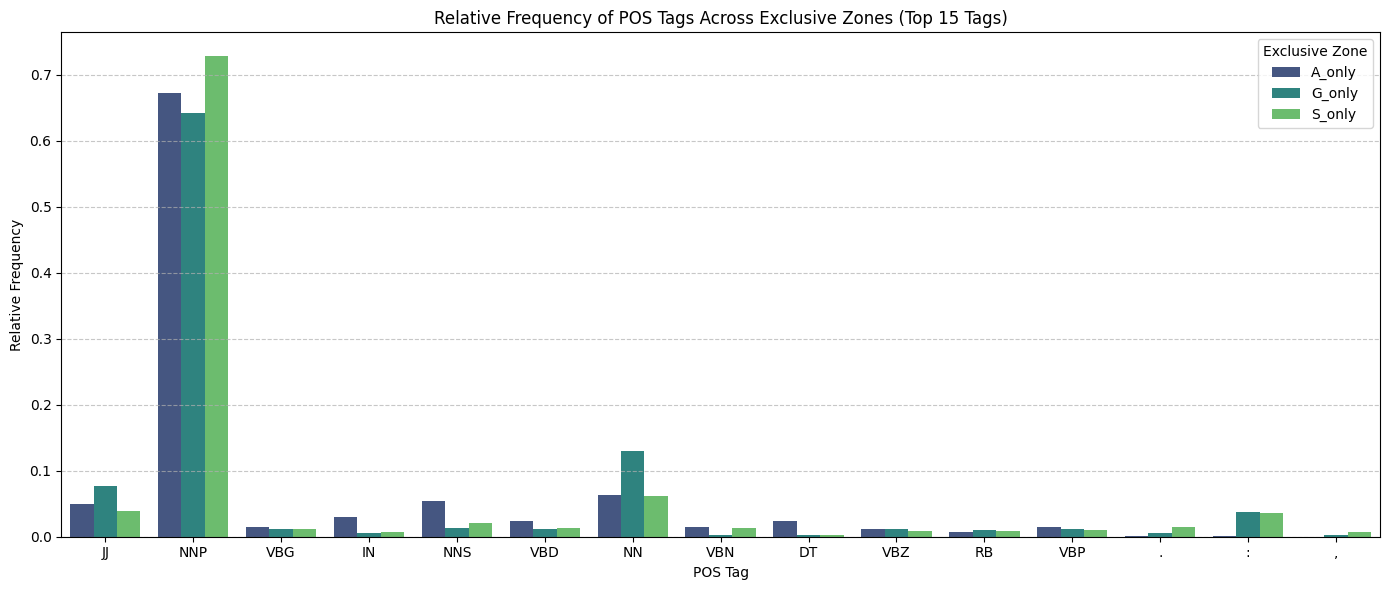

In [6]:
import json
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Ensure required NLTK packages are downloaded
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# Load the bridge results
with open('bridge_results.json') as f:
    d = json.load(f)

zones = d.get('token_zones', {})
pos_data = []

# Process each exclusive zone
for zone_name in ['A_only', 'G_only', 'S_only']:
    if zone_name not in zones:
        continue

    # Reconstruct the flat list of count-weighted tokens
    tokens = []
    for tok, count in zones[zone_name].items():
        tokens.extend([tok] * int(count))

    # Tag the tokens
    tagged = nltk.pos_tag(tokens)
    pos_counts = Counter([tag for _, tag in tagged])

    # Calculate relative frequency to compare fairly across zones
    total_tokens = sum(pos_counts.values())
    for tag, count in pos_counts.items():
        pos_data.append({
            'Zone': zone_name,
            'POS Tag': tag,
            'Frequency': count / total_tokens
        })

df_pos = pd.DataFrame(pos_data)

# Select the top 15 POS tags overall for a cleaner chart
top_tags = df_pos.groupby('POS Tag')['Frequency'].sum().nlargest(15).index
df_pos_top = df_pos[df_pos['POS Tag'].isin(top_tags)]

# Plotting
plt.figure(figsize=(14, 6))
sns.barplot(data=df_pos_top, x='POS Tag', y='Frequency', hue='Zone', palette='viridis')
plt.title('Relative Frequency of POS Tags Across Exclusive Zones (Top 15 Tags)')
plt.ylabel('Relative Frequency')
plt.xlabel('POS Tag')
plt.legend(title='Exclusive Zone')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### What Got Missed: Top Unique Tokens per Method
This table shows the top 15 specific tokens that were highly attributed by one method but **completely missed** by the other two. This reveals the concrete linguistic structures driving the divergence.

In [7]:
import json
import pandas as pd
from IPython.display import display

# Load the bridge results to get the token zones
with open('bridge_results.json') as f:
    d = json.load(f)

zones = d.get('token_zones', {})
top_unique_tokens = {}

# Extract the top 15 most frequent tokens in each exclusive zone
for zone in ['A_only', 'G_only', 'S_only']:
    if zone in zones:
        # Sort tokens by their frequency in this exclusive zone
        sorted_tokens = sorted(zones[zone].items(), key=lambda item: item[1], reverse=True)
        # Format as 'token' (count) for easy reading
        top_unique_tokens[zone] = [f"{repr(tok)} (n={count})" for tok, count in sorted_tokens[:15]]

# Create a DataFrame for side-by-side comparison
df_missed = pd.DataFrame(top_unique_tokens)
df_missed.index = [f"Rank {i+1}" for i in range(15)]

print("Top specific tokens uniquely captured by one method (missed by the others):")
display(df_missed)


Top specific tokens uniquely captured by one method (missed by the others):


,A_only,G_only,S_only
Rank 1,'<|endoftext|>' (n=1674),' the' (n=757),' .' (n=1840)
Rank 2,"' ,' (n=1196)",'-' (n=581),"' ,' (n=1352)"
Rank 3,' .' (n=1118),' of' (n=308),"' ""' (n=747)"
Rank 4,'The' (n=284),' in' (n=163),'@' (n=717)
Rank 5,' @' (n=265),' and' (n=145),' of' (n=653)
Rank 6,' was' (n=205),' a' (n=133),'-' (n=585)
Rank 7,' of' (n=201),' to' (n=97),' the' (n=474)
Rank 8,'In' (n=155),'@' (n=93),' @' (n=440)
Rank 9,' the' (n=122),'.' (n=79),' and' (n=349)
Rank 10,' in' (n=121),""" '"" (n=77)",' (' (n=313)


### Beyond the Top 15: Filtered Unique Tokens
By blacklisting the highly frequent (and often structural/syntactic) top 15 tokens from each method, we can peel back a layer and see what secondary patterns emerge in the divergence.

In [8]:
import json
import pandas as pd
from IPython.display import display

# Re-load zones if not in memory
with open('bridge_results.json') as f:
    d = json.load(f)
zones = d.get('token_zones', {})

# 1. Build the blacklist from the top 15 of each zone
blacklist = set()
for zone in ['A_only', 'G_only', 'S_only']:
    if zone in zones:
        sorted_tokens = sorted(zones[zone].items(), key=lambda item: item[1], reverse=True)
        for tok, _ in sorted_tokens[:15]:
            blacklist.add(tok)

print(f"Blacklisted {len(blacklist)} unique high-frequency tokens across all methods.")

# 2. Extract the next top 15 tokens ignoring the blacklist
next_unique_tokens = {}
for zone in ['A_only', 'G_only', 'S_only']:
    if zone in zones:
        # Filter out blacklisted tokens
        filtered_tokens = [(tok, count) for tok, count in zones[zone].items() if tok not in blacklist]
        # Sort remaining
        sorted_filtered = sorted(filtered_tokens, key=lambda item: item[1], reverse=True)
        # Format for display
        next_unique_tokens[zone] = [f"{repr(tok)} (n={count})" for tok, count in sorted_filtered[:15]]

# 3. Display the results
df_next_missed = pd.DataFrame(next_unique_tokens)
df_next_missed.index = [f"Rank {i+16}" for i in range(15)]

print("\nTop specific tokens uniquely captured by one method (excluding the top 15 blacklist):")
display(df_next_missed)


Blacklisted 27 unique high-frequency tokens across all methods.

Top specific tokens uniquely captured by one method (excluding the top 15 blacklist):


,A_only,G_only,S_only
Rank 16,'On' (n=74),' The' (n=67),' with' (n=138)
Rank 17,' for' (n=70),' D' (n=60),"',' (n=123)"
Rank 18,' with' (n=69),' T' (n=57),' The' (n=113)
Rank 19,' Nero' (n=65),' for' (n=57),' from' (n=98)
Rank 20,' ;' (n=64),' F' (n=55),' at' (n=85)
Rank 21,' on' (n=55),' P' (n=55),' )' (n=83)
Rank 22,' were' (n=55),' J' (n=51),' =' (n=79)
Rank 23,'nar' (n=55),' K' (n=49),' for' (n=73)
Rank 24,' he' (n=45),' American' (n=47),' on' (n=60)
Rank 25,' from' (n=38),'int' (n=46),' :' (n=49)


### Recursive Token Blacklist and Sentence Context
This block runs iteratively. In each pass, it identifies the top 15 tokens per method, adds them to a cumulative blacklist, and then searches the dataset for sentences (bounded by `.`) that contain these newly flagged tokens. This demonstrates how the models' attention shifts from stopwords/syntax to more complex semantic features.

In [16]:
import json
import pandas as pd
from datasets import load_dataset
from IPython.display import display, HTML

# 1. Load dataset to extract actual sentence contexts
print("Loading WikiText-103 to extract sentence contexts...")
ds = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1", split="test")

# Concatenate a chunk of text and split by period to define sentences
text_chunk = " ".join([row['text'] for row in ds.select(range(1000)) if row['text'].strip()])
# Define sentence by period boundary
sentences = [s.strip() + "." for s in text_chunk.split('.') if len(s.strip()) > 20]

# 2. Load Bridge Results
with open('bridge_results.json') as f:
    d = json.load(f)
zones = d.get('token_zones', {})

# 3. Recursive Blacklisting Configuration
num_passes = 4
tokens_per_pass = 15
cumulative_blacklist = set()

for p in range(1, num_passes + 1):
    display(HTML(f"<h3 style='color: #2c3e50;'>Pass {p} (Cumulative Blacklist: {len(cumulative_blacklist)} tokens)</h3>"))

    current_pass_tokens = {}
    pass_search_set = set()

    # Identify top tokens for this pass
    for zone in ['A_only', 'G_only', 'S_only']:
        if zone in zones:
            # Filter out tokens that were caught in previous passes
            available = [(tok, count) for tok, count in zones[zone].items() if tok not in cumulative_blacklist]
            top_k = sorted(available, key=lambda x: x[1], reverse=True)[:tokens_per_pass]
            current_pass_tokens[zone] = [f"{repr(t)} (n={c})" for t, c in top_k]

            for t, _ in top_k:
                cumulative_blacklist.add(t)
                # For meaningful sentence search, only look for tokens with alphabetical characters
                if len(t.strip()) > 1 and any(c.isalpha() for c in t):
                    pass_search_set.add(t)

    # Display the token dataframe for this pass
    df = pd.DataFrame(current_pass_tokens)
    df.index = [f"Rank {i+1}" for i in range(tokens_per_pass)]
    display(df)

    # Find and display example sentences using character spans
    print("\n  Example flagged sentences (Tokens highlighted):")
    found = 0
    for sentence in sentences:
        spans = []
        for t in pass_search_set:
            start = 0
            while True:
                start = sentence.find(t, start)
                if start == -1:
                    break
                spans.append((start, start + len(t)))
                start += 1

        if spans:
            # Merge overlapping spans
            spans.sort(key=lambda x: x[0])
            merged_spans = []
            for s in spans:
                if not merged_spans:
                    merged_spans.append(s)
                else:
                    prev_start, prev_end = merged_spans[-1]
                    curr_start, curr_end = s
                    if curr_start <= prev_end: # Overlap detected
                        merged_spans[-1] = (prev_start, max(prev_end, curr_end))
                    else:
                        merged_spans.append(s)

            # Apply highlighting from right to left to avoid index shifting
            highlighted = sentence
            for start, end in reversed(merged_spans):
                highlighted = highlighted[:start] + f"\033[1;31m{highlighted[start:end]}\033[0m" + highlighted[end:]

            # Clean up extra spaces
            highlighted = " ".join(highlighted.split())
            print(f"  -> {highlighted}")
            found += 1

        if found >= 3:  # Show 3 examples per pass
            break

    if found == 0:
        print("  -> (No clear sentence matches found for these specific tokens in the sample chunk)")
    print("\n" + "="*80 + "\n")


Loading WikiText-103 to extract sentence contexts...


,A_only,G_only,S_only
Rank 1,'<|endoftext|>' (n=1674),'-' (n=581),"' ""' (n=747)"
Rank 2,"' ,' (n=1196)",' a' (n=133),' by' (n=212)
Rank 3,' .' (n=1118),'@' (n=93),' as' (n=181)
Rank 4,'The' (n=284),'.' (n=79),' with' (n=138)
Rank 5,' @' (n=265),""" '"" (n=77)","',' (n=123)"
Rank 6,' was' (n=205),'s' (n=74),' from' (n=98)
Rank 7,' of' (n=201),' his' (n=73),' at' (n=85)
Rank 8,'In' (n=155),' B' (n=71),' )' (n=83)
Rank 9,' the' (n=122),'n' (n=67),' =' (n=79)
Rank 10,' in' (n=121),' The' (n=67),' on' (n=60)



  Example flagged sentences (Tokens highlighted):
  -> = Robert Boulter = Robert Boulter is an English film , television and theatre actor.
  -> He had a guest @-@ starring role on the television series The Bill in 2000.
  -> This was followed by a starring role in the play Herons written by Simon Stephens , which was performed in 2001 at the Royal Court Theatre.




,A_only,G_only,S_only
Rank 1,'On' (n=74),' J' (n=51),'a' (n=40)
Rank 2,' Nero' (n=65),' K' (n=49),' against' (n=38)
Rank 3,' ;' (n=64),' American' (n=47),' along' (n=34)
Rank 4,' were' (n=55),'int' (n=46),' near' (n=32)
Rank 5,'nar' (n=55),'�' (n=44),' including' (n=31)
Rank 6,' he' (n=45),' re' (n=43),' when' (n=29)
Rank 7,'ers' (n=37),' V' (n=43),' or' (n=28)
Rank 8,' had' (n=36),' iron' (n=42),'B' (n=28)
Rank 9,' He' (n=34),'osp' (n=42),' named' (n=27)
Rank 10,' has' (n=34),' N' (n=39),' which' (n=27)



  Example flagged sentences (Tokens highlighted):
  -> = Robert Boulter = Robert Boulter is an English film , television and theatre actor.
  -> He had a guest @-@ starring role on the television series The Bill in 2000.
  -> This was followed by a starring role in the play Herons written by Simon Stephens , which was performed in 2001 at the Royal Court Theatre.




,A_only,G_only,S_only
Rank 1,'ila' (n=24),' I' (n=34),' �' (n=23)
Rank 2,'During' (n=23),'an' (n=32),' day' (n=23)
Rank 3,' ships' (n=23),' tropical' (n=32),' after' (n=23)
Rank 4,'ads' (n=20),' L' (n=31),' however' (n=21)
Rank 5,'ulu' (n=20),'ir' (n=31),' between' (n=21)
Rank 6,' Philippines' (n=19),'th' (n=30),' 1' (n=21)
Rank 7,' WWE' (n=19),'al' (n=29),' included' (n=21)
Rank 8,'At' (n=18),' all' (n=28),' led' (n=18)
Rank 9,' North' (n=18),' U' (n=28),' Operation' (n=18)
Rank 10,' Division' (n=18),'j' (n=28),' result' (n=18)



  Example flagged sentences (Tokens highlighted):
  -> = Robert Boulter = Robert Boulter is an English film , television and theatre actor.
  -> He had a guest @-@ starring role on the television series The Bill in 2000.
  -> This was followed by a starring role in the play Herons written by Simon Stephens , which was performed in 2001 at the Royal Court Theatre.




,A_only,G_only,S_only
Rank 1,' Company' (n=17),'az' (n=26),' like' (n=16)
Rank 2,' Beauty' (n=17),'or' (n=25),'ia' (n=16)
Rank 3,' but' (n=16),' W' (n=24),' Lorenzo' (n=16)
Rank 4,' where' (n=16),' H' (n=24),' end' (n=15)
Rank 5,'haw' (n=16),'it' (n=24),' over' (n=15)
Rank 6,' Commission' (n=16),' its' (n=23),' while' (n=15)
Rank 7,' Gibraltar' (n=16),' their' (n=23),' year' (n=14)
Rank 8,' began' (n=15),' All' (n=23),' well' (n=14)
Rank 9,' album' (n=15),'i' (n=23),' 4' (n=14)
Rank 10,' Hitler' (n=15),'etr' (n=23),' using' (n=14)



  Example flagged sentences (Tokens highlighted):
  -> = Robert Boulter = Robert Boulter is an English film , television and theatre actor.
  -> This was followed by a starring role in the play Herons written by Simon Stephens , which was performed in 2001 at the Royal Court Theatre.
  -> He had a guest role in the television series Judge John Deed in 2002.




### Dual-Color Visualization: Convergence vs. Divergence
*   **[1;34mBLUE (Convergent)[0m**: Tokens flagged by ALL methods (Attention, Gradient, SAE). These are the consensus, load-bearing tokens of the sentence.
*   **[1;31mRED (Divergent)[0m**: Tokens flagged by ONLY ONE method. These reveal the specialized, mechanistic quirks of the model's internal routing.

In [18]:
import json
from datasets import load_dataset
from IPython.display import HTML, display

# 1. Load dataset & Prepare sentences by length
ds = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1", split="test")
text_chunk = " ".join([row['text'] for row in ds.select(range(1000)) if row['text'].strip()])
sentences = [s.strip() + "." for s in text_chunk.split('.') if len(s.strip()) > 20]

# Categorize sentences into length buckets
sentence_buckets = {'Short (<15 words)': [], 'Medium (15-30 words)': [], 'Long (>30 words)': []}
for s in sentences:
    words = len(s.split())
    if words < 15:
        sentence_buckets['Short (<15 words)'].append(s)
    elif words <= 30:
        sentence_buckets['Medium (15-30 words)'].append(s)
    else:
        sentence_buckets['Long (>30 words)'].append(s)

# 2. Load Bridge Results
with open('bridge_results.json') as f:
    d = json.load(f)
zones = d.get('token_zones', {})

# 2.5 Extract Missed Tokens from DataFrames
missed_tokens = set()
if 'df_missed' in globals():
    for col in df_missed.columns:
        for val in df_missed[col]:
            tok = eval(val.rsplit(' (n=', 1)[0])
            if len(tok.strip()) > 1 and any(c.isalpha() for c in tok):
                missed_tokens.add(tok)
if 'df_next_missed' in globals():
    for col in df_next_missed.columns:
        for val in df_next_missed[col]:
            tok = eval(val.rsplit(' (n=', 1)[0])
            if len(tok.strip()) > 1 and any(c.isalpha() for c in tok):
                missed_tokens.add(tok)

# 3. Recursive Visualization Setup (Tri-Color)
num_passes = 4
cumulative_blacklist = set()

for p in range(1, num_passes + 1):
    display(HTML(f"<h3 style='color: #2c3e50;'>Pass {p} (Cumulative Blacklist: {len(cumulative_blacklist)} tokens)</h3>"))

    # Function to get top tokens ignoring the cumulative blacklist
    def get_available_tokens(zone_name, k=30):
        if zone_name not in zones: return set()
        available = [(t, c) for t, c in zones[zone_name].items() if t not in cumulative_blacklist]
        sorted_toks = sorted(available, key=lambda x: x[1], reverse=True)
        return set([t for t, c in sorted_toks[:k] if len(t.strip()) > 1 and any(char.isalpha() for char in t)])

    # Convergent (Blue): Top tokens from the 'triple' intersection
    convergent_tokens = get_available_tokens('triple', 40)

    # Raw Divergent: Top tokens from the exclusive zones for this pass
    raw_divergent = set()
    for z in ['A_only', 'G_only', 'S_only']:
        raw_divergent.update(get_available_tokens(z, 20))

    # Ensure no accidental overlap
    raw_divergent = raw_divergent - convergent_tokens

    # Missed (Green): Divergent tokens in this pass that are in our historical list
    pass_missed_tokens = raw_divergent & missed_tokens

    # Divergent (Red): Divergent tokens in this pass that are new/not in historical list
    divergent_tokens = raw_divergent - pass_missed_tokens

    print(f"Highlighting {len(convergent_tokens)} Convergent (BLUE), {len(divergent_tokens)} Divergent (RED), and {len(pass_missed_tokens)} Missed (GREEN).")

    # Update cumulative blacklist for the next pass
    cumulative_blacklist.update(convergent_tokens)
    cumulative_blacklist.update(raw_divergent)

    # 4. Highlight Sentences by Bucket
    for bucket_name, bucket_sentences in sentence_buckets.items():
        print(f"\n  [{bucket_name}]")
        found = 0
        for sentence in bucket_sentences:
            spans = []

            # Find Convergent spans (Blue)
            for t in convergent_tokens:
                start = 0
                while True:
                    start = sentence.find(t, start)
                    if start == -1: break
                    spans.append((start, start + len(t), 'blue'))
                    start += 1

            # Find Divergent spans (Red)
            for t in divergent_tokens:
                start = 0
                while True:
                    start = sentence.find(t, start)
                    if start == -1: break
                    spans.append((start, start + len(t), 'red'))
                    start += 1

            # Find Missed spans (Green)
            for t in pass_missed_tokens:
                start = 0
                while True:
                    start = sentence.find(t, start)
                    if start == -1: break
                    spans.append((start, start + len(t), 'green'))
                    start += 1

            if spans:
                # Merge overlaps
                spans.sort(key=lambda x: x[0])
                merged = []
                for s in spans:
                    if not merged:
                        merged.append(s)
                    else:
                        prev_start, prev_end, prev_color = merged[-1]
                        curr_start, curr_end, curr_color = s
                        if curr_start < prev_end:
                            # Overlap: extend end, keep original color
                            merged[-1] = (prev_start, max(prev_end, curr_end), prev_color)
                        else:
                            merged.append(s)

                # Apply highlighting right-to-left
                highlighted = sentence
                for start, end, color in reversed(merged):
                    ansi_code = "\033[1;34m" if color == 'blue' else "\033[1;31m" if color == 'red' else "\033[1;32m"
                    highlighted = highlighted[:start] + f"{ansi_code}{highlighted[start:end]}\033[0m" + highlighted[end:]

                # Ensure we only show sentences that have Convergent + at least one Divergent/Missed color to prove the point
                if ("\033[1;34m" in highlighted) and ("\033[1;31m" in highlighted or "\033[1;32m" in highlighted):
                    highlighted = " ".join(highlighted.split())
                    print(f"    -> {highlighted}")
                    found += 1

            if found >= 2: # Show 2 examples per length bucket
                break

        if found == 0:
            print("    -> (No clear sentence matches found with required colors for this bucket)")

    print("\n" + "="*80 + "\n")


Highlighting 21 Convergent (BLUE), 0 Divergent (RED), and 9 Missed (GREEN).

  [Short (<15 words)]
    -> He appeared on the television series Survivors as " Neil " in November 2008.
    -> He failed , to his surprise and that of centuries of later critics.

  [Medium (15-30 words)]
    -> = Robert Boulter = Robert Boulter is an English film , television and theatre actor.
    -> He had a guest @-@ starring role on the television series The Bill in 2000.

  [Long (>30 words)]
    -> In 2004 Boulter landed a role as " Craig " in the episode " Teddy 's Story " of the television series The Long Firm ; he starred alongside actors Mark Strong and Derek Jacobi.
    -> He was cast in the 2005 theatre productions of the Philip Ridley play Mercury Fur , which was performed at the Drum Theatre in Plymouth and the Menier Chocolate Factory in London.




Highlighting 14 Convergent (BLUE), 4 Divergent (RED), and 14 Missed (GREEN).

  [Short (<15 words)]
    -> He had a guest role in the television series Judge John Deed in 2002.
    -> He had an elder brother , who died young.

  [Medium (15-30 words)]
    -> He had a guest @-@ starring role on the television series The Bill in 2000.
    -> This was followed by a starring role in the play Herons written by Simon Stephens , which was performed in 2001 at the Royal Court Theatre.

  [Long (>30 words)]
    -> In 2004 Boulter landed a role as " Craig " in the episode " Teddy 's Story " of the television series The Long Firm ; he starred alongside actors Mark Strong and Derek Jacobi.
    -> He was cast in the 2005 theatre productions of the Philip Ridley play Mercury Fur , which was performed at the Drum Theatre in Plymouth and the Menier Chocolate Factory in London.




Highlighting 11 Convergent (BLUE), 9 Divergent (RED), and 2 Missed (GREEN).

  [Short (<15 words)]
    -> @ 0 in ) torpedo tubes , three on each broadside.

  [Medium (15-30 words)]
    -> Afterwards both ships were transferred to Southeast Asia ; in early 1945 they participated in Operation Kita , where they transported petrol and other strategic materials to Japan.
    -> During the ships ' modernization during the 1930s , their forward superstructures were enlarged with multiple platforms added to their tripod foremasts.

  [Long (>30 words)]
    -> During their 1930s modernization , the boilers on each ship were replaced by eight new Kampon oil @-@ fired boilers , fitted into the former aft boiler room , and the forward funnel was removed.
    -> During the mid @-@ 1930s reconstruction the torpedo tubes were removed and the Vickers two @-@ pounders were replaced by twenty license @-@ built Hotchkiss 25 mm Type 96 light AA guns in 10 twin @-@ gun mounts.




Highlighting 10 Convergent (BLUE), 9 Divergent (RED), and 0 Missed (GREEN).

  [Short (<15 words)]
    -> (No clear sentence matches found with required colors for this bucket)

  [Medium (15-30 words)]
    -> = Robert Boulter = Robert Boulter is an English film , television and theatre actor.
    -> = = Translation = = A variety of styles have been used in efforts to translate Du Fu 's work into English.

  [Long (>30 words)]
    -> Vikram Seth in Three Chinese Poets uses English @-@ style rhyme schemes , whereas Keith Holyoak in Facing the Moon approximates the Chinese rhyme scheme ; both use end @-@ stopped lines and preserve some degree of parallelism.
    -> = = = = Battle of Cape Engaño = = = = Shortages of aircraft and serviceability problems greatly retarded pilot training and the ships only had a total of 17 D4Ys and 18 E16As on hand on 1 October ; of these , only 6 and 16 were operational , respectively.




In [19]:
import json, html
from collections import Counter
from IPython.display import HTML, display

COLOR = {"triple":"#1f6feb","A_only":"#d29922","G_only":"#2da44e","S_only":"#a371f7"}
LABEL = {"triple":"all 3","A_only":"attention","G_only":"gradient","S_only":"SAE"}

def _chip(t, z):
    return (f"<span style='display:inline-block;margin:1px 3px;padding:1px 5px;border-radius:3px;"
            f"background:{COLOR[z]}22;color:{COLOR[z]};font-weight:600'>{html.escape(t)}</span>")

def render(path="bridge_results.json", max_prompts=12, require_mix=True):
    d = json.load(open(path)); recs = d.get("per_prompt", [])
    legend = " &nbsp; ".join(f"<span style='color:{COLOR[z]};font-weight:600'>&#9632;</span> {LABEL[z]}"
                             for z in COLOR)
    display(HTML(f"<div style='font-family:monospace;margin-bottom:8px'>{legend}</div>"))
    corpus = Counter(); shown = 0
    for r in recs:
        comp = {z: r.get(z, []) for z in COLOR}
        for z in ("A_only","G_only","S_only"): corpus[z] += len(comp[z])
        div = sum(len(comp[z]) for z in ("A_only","G_only","S_only"))
        if require_mix and (len(comp["triple"]) == 0 or div < 2):
            continue
        cols = []
        for z in ("triple","A_only","G_only","S_only"):
            chips = "".join(_chip(t, z) for t in comp[z]) or "<span style='color:#6e7681'>—</span>"
            cols.append(f"<td style='vertical-align:top;padding:3px 10px'>"
                        f"<div style='color:{COLOR[z]};font-size:11px;font-weight:600'>{LABEL[z]} ({len(comp[z])})</div>{chips}</td>")
        display(HTML(f"<table style='font-family:monospace;font-size:12px;border-left:3px solid #30363d;"
                     f"margin:4px 0'><tr>{''.join(cols)}</tr></table>"))
        shown += 1
        if shown >= max_prompts: break
    tot = sum(corpus.values()) or 1
    rows = " · ".join(f"{LABEL[z]} {corpus[z]} ({corpus[z]/tot:.0%})" for z in ("A_only","G_only","S_only"))
    display(HTML(f"<div style='font-family:monospace;margin-top:8px'>divergent mass by method &nbsp; {rows}</div>"))

render()

all 3 (1) of,"attention (3) ,icism '",gradient (6) Fu strong of history moral technical,"SAE (6) his engagement , and his excellence"


all 3 (1) the,attention (4)<|endoftext|>In sailed food,gradient (4) and Ele theuther,SAE (5) a to deliver materialsa


all 3 (3) = ( @,attention (2) debut Formation,gradient (2)- 1994,SAE (3) ) = =


all 3 (5)= = and ( ),attention (0)—,gradient (1) Black,SAE (4)out 2004 = =


all 3 (2)=ize,attention (1) Records,gradient (2) New Album,SAE (5) and Evolution ) = =


...

"all 3 (3) , ( Wes",attention (3)<|endoftext|>er guitar,gradient (1) 1994,SAE (3) Geer )


all 3 (4). — ( B,attention (2)aught drums,gradient (2) C V,SAE (2) 2003.


all 3 (1) —,attention (0)—,gradient (2)nt Product,SAE (3) ( 2013 samples


"all 3 (4) "" — ( 2007",attention (0)—,gradient (1)ius,SAE (3)oz 2008


"all 3 (1) ,",attention (8)<|endoftext|> 1862 navies adoptedads . Britain,gradient (8) broad- m Gl L either iron British,SAE (9) involved ironads . using and . of iron


### Layer-wise Convergence (Focus on L9-L11)
Let's visualize how the agreement between Attention, Gradient, and SAEs evolves as we move deeper into the model, specifically looking at the late-stage semantic layers (9 through 11).

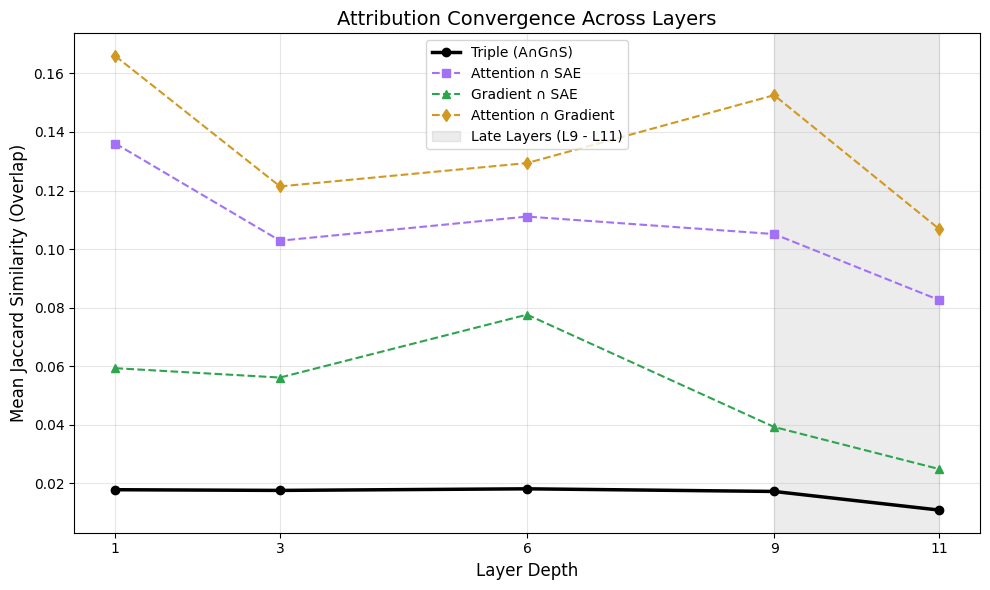


Quantitative Shift from Layer 9 to Layer 11:


,Triple Convergence (A∩G∩S),Attention ∩ SAE (A∩S),Gradient ∩ SAE (G∩S),Attention ∩ Gradient (A∩G)
Layer,,,,
9,0.017169,0.105123,0.039198,0.152584
11,0.010824,0.082627,0.024854,0.106942


In [20]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Load the bridge results
with open('bridge_results.json') as f:
    d = json.load(f)

layer_summaries = d.get('per_layer_summary', {})
layers = sorted([int(l) for l in layer_summaries.keys()])

data = []
for l in layers:
    metrics = layer_summaries[str(l)]
    data.append({
        'Layer': l,
        'Triple Convergence (A∩G∩S)': metrics['conv_triple'][0],
        'Attention ∩ SAE (A∩S)': metrics['conv_A_S'][0],
        'Gradient ∩ SAE (G∩S)': metrics['conv_G_S'][0],
        'Attention ∩ Gradient (A∩G)': metrics['conv_A_G'][0]
    })

df_layers = pd.DataFrame(data)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(df_layers['Layer'], df_layers['Triple Convergence (A∩G∩S)'], marker='o', label='Triple (A∩G∩S)', linewidth=2.5, color='black')
plt.plot(df_layers['Layer'], df_layers['Attention ∩ SAE (A∩S)'], marker='s', label='Attention ∩ SAE', linestyle='--', color='#a371f7')
plt.plot(df_layers['Layer'], df_layers['Gradient ∩ SAE (G∩S)'], marker='^', label='Gradient ∩ SAE', linestyle='--', color='#2da44e')
plt.plot(df_layers['Layer'], df_layers['Attention ∩ Gradient (A∩G)'], marker='d', label='Attention ∩ Gradient', linestyle='--', color='#d29922')

# Highlight Late Layers (9-11)
plt.axvspan(9, 11, color='gray', alpha=0.15, label='Late Layers (L9 - L11)')

plt.title('Attribution Convergence Across Layers', fontsize=14)
plt.xlabel('Layer Depth', fontsize=12)
plt.ylabel('Mean Jaccard Similarity (Overlap)', fontsize=12)
plt.xticks(layers)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nQuantitative Shift from Layer 9 to Layer 11:")
display(df_layers[df_layers['Layer'].isin([9, 11])].set_index('Layer'))

### Experiment: Zero-Shot Syntactic Tax Ablation
Testing if projecting out a convergent syntactic vector from the residual stream prior to SAE encoding frees up feature capacity (L0) on structural tokens.

Loading GPT-2 Small and Layer 9 SAE...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2 into HookedTransformer
Moving model to device:  cuda


/usr/local/lib/python3.12/dist-packages/sae_lens/saes/sae.py:251: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


Isolating Syntactic Subspace from Convergent Stopwords...
Running Evaluation...


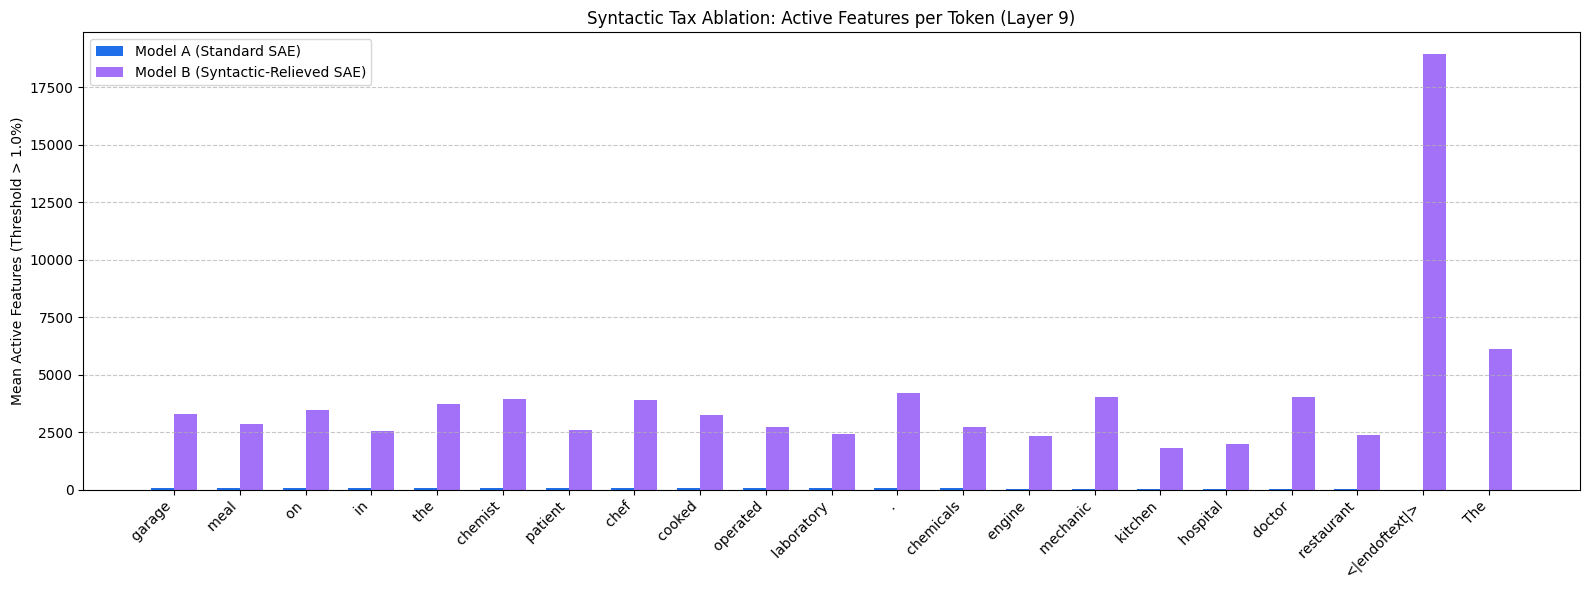


Total SAE Feature Activations (Model A): 2277
Total SAE Feature Activations (Model B): 214168
Capacity Freed by Syntactic Ablation: -211891 features (-9305.7%) 


In [23]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer
from sae_lens import SAE

device = "cuda" if torch.cuda.is_available() else "cpu"

# 1. Load Model and SAE (Layer 9)
print("Loading GPT-2 Small and Layer 9 SAE...")
model = HookedTransformer.from_pretrained("gpt2").to(device)
model.eval()
sae = SAE.from_pretrained("gpt2-small-res-jb", "blocks.9.hook_resid_pre", device=device)

# 2. Isolate the "Syntactic Tax" Subspace
print("Isolating Syntactic Subspace from Convergent Stopwords...")
# Using the convergent 'blue' tokens from our previous analysis
stopwords = [" the", " in", " and", " is", " to", " of", " a", " it", " that", " for", " on", " as", " with", " by"]
stop_text = " ".join(stopwords)
stop_toks = model.to_tokens(stop_text)

with torch.no_grad():
    _, cache = model.run_with_cache(stop_toks, names_filter="blocks.9.hook_resid_pre")
stop_resid = cache["blocks.9.hook_resid_pre"][0, 1:] # Ignore BOS
syntax_dir = stop_resid.mean(dim=0)
syntax_dir = syntax_dir / syntax_dir.norm() # Unit vector

# 3. Define Test Sentences (Similar Syntax, Different Semantics)
sentences = [
    "The doctor operated on the patient in the hospital.", # Medical
    "The mechanic operated on the engine in the garage.",  # Mechanical
    "The chef cooked the meal in the restaurant kitchen.", # Culinary
    "The chemist cooked the chemicals in the laboratory."  # Scientific
]

# 4. Run Model A (Standard) vs Model B (Tax-Relieved)
results = []
threshold_ratio = 0.01 # Normalized threshold (1% of max activation)

print("Running Evaluation...")
for text in sentences:
    toks = model.to_tokens(text)
    str_toks = model.to_str_tokens(text)

    with torch.no_grad():
        _, c = model.run_with_cache(toks, names_filter="blocks.9.hook_resid_pre")
        resid = c["blocks.9.hook_resid_pre"][0] # [seq_len, d_model]

        # Model A: Standard Encoding
        acts_A = sae.encode(resid)
        thresh_A = acts_A.max(dim=-1, keepdim=True)[0] * threshold_ratio
        l0_A = (acts_A > thresh_A).float().sum(dim=-1).cpu().numpy()

        # Model B: Syntactic-Relieved Encoding
        # Project out the syntax direction
        proj = (resid @ syntax_dir).unsqueeze(-1) * syntax_dir
        resid_B = resid - proj
        acts_B = sae.encode(resid_B)
        thresh_B = acts_B.max(dim=-1, keepdim=True)[0] * threshold_ratio
        l0_B = (acts_B > thresh_B).float().sum(dim=-1).cpu().numpy()

        for i, tok in enumerate(str_toks):
            results.append({
                "Sentence": text,
                "Token": tok,
                "Position": i,
                "Model A (Standard L0)": l0_A[i],
                "Model B (Relieved L0)": l0_B[i],
                "L0 Reduction": l0_A[i] - l0_B[i]
            })

df_exp = pd.DataFrame(results)

# 5. Visualize the Impact
# Aggregate L0 by token across all sentences
df_agg = df_exp.groupby("Token")[["Model A (Standard L0)", "Model B (Relieved L0)"]].mean().reset_index()
# Sort by Standard L0 for better visualization
df_agg = df_agg.sort_values("Model A (Standard L0)", ascending=False)

x = np.arange(len(df_agg))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - width/2, df_agg["Model A (Standard L0)"], width, label='Model A (Standard SAE)', color='#1f6feb')
ax.bar(x + width/2, df_agg["Model B (Relieved L0)"], width, label='Model B (Syntactic-Relieved SAE)', color='#a371f7')

ax.set_ylabel(f'Mean Active Features (Threshold > {threshold_ratio*100}%)')
ax.set_title('Syntactic Tax Ablation: Active Features per Token (Layer 9)')
ax.set_xticks(x)
ax.set_xticklabels(df_agg["Token"], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Summarize Total Capacity Freed
total_a = df_exp["Model A (Standard L0)"].sum()
total_b = df_exp["Model B (Relieved L0)"].sum()
saved = total_a - total_b
print(f"\nTotal SAE Feature Activations (Model A): {total_a:.0f}")
print(f"Total SAE Feature Activations (Model B): {total_b:.0f}")
print(f"Capacity Freed by Syntactic Ablation: {saved:.0f} features ({saved/total_a*100:.1f}%) ")

In [24]:
import pandas as pd
import torch
from IPython.display import display, HTML

# 1. Use the first sentence from our previous list
text = sentences[0]
toks = model.to_tokens(text)
str_toks = model.to_str_tokens(text)

print(f"Analyzing sentence: '{text}'\n")

# 2. Get activations for Model A and Model B
with torch.no_grad():
    _, c = model.run_with_cache(toks, names_filter="blocks.9.hook_resid_pre")
    resid = c["blocks.9.hook_resid_pre"][0]

    # Model A Encoding
    acts_A = sae.encode(resid)

    # Model B Encoding (Relieved)
    proj = (resid @ syntax_dir).unsqueeze(-1) * syntax_dir
    resid_B = resid - proj
    acts_B = sae.encode(resid_B)

# 3. Pick specific tokens to inspect: mix of semantic and syntactic
target_tokens = [" doctor", " operated", " in", " hospital"]
indices_to_check = [i for i, t in enumerate(str_toks) if t in target_tokens]

top_k = 5
comparison_data = []

for i in indices_to_check:
    tok = str_toks[i]
    vals_A, idx_A = torch.topk(acts_A[i], top_k)
    vals_B, idx_B = torch.topk(acts_B[i], top_k)

    for rank in range(top_k):
        comparison_data.append({
            "Token": f"{repr(tok)} (pos {i})",
            "Rank": rank + 1,
            "Model A (Standard) Feature": f"F{idx_A[rank].item()} ({vals_A[rank].item():.2f})",
            "Model B (Relieved) Feature": f"F{idx_B[rank].item()} ({vals_B[rank].item():.2f})",
        })

df_comp = pd.DataFrame(comparison_data)

# 4. Display as a clean table
display(HTML("<b>Top 5 Active Features per Token (Model A vs Model B)</b>"))
display(df_comp.set_index(["Token", "Rank"]))


Analyzing sentence: 'The doctor operated on the patient in the hospital.'



Model A (Standard) Feature Model B (Relieved) Feature
Token               Rank                                                      
' doctor' (pos 2)   1                 F4483 (41.96)              F4483 (51.11)
                    2                 F1926 (18.62)             F14340 (27.69)
                    3                F14340 (13.65)              F1926 (27.13)
                    4                F24338 (11.58)             F19520 (23.67)
                    5                  F4894 (5.92)             F12749 (21.05)
' operated' (pos 3) 1                 F5259 (35.59)              F5259 (44.79)
                    2                F10935 (12.80)              F4421 (18.94)
                    3                  F4421 (8.44)             F10935 (18.75)
                    4                  F6053 (7.92)              F1311 (17.32)
                    5                  F9847 (5.35)              F1245 (16.98)
' in' (pos 7)       1                F17327 (14.10)             F17327 (20.35)
                    2                F21161 (13.81)             F21161 (19.36)
                    3                 F12114 (8.31)             F15267 (14.39)
                    4                 F15267 (8.11)             F15534 (14.05)
                    5                 F18596 (6.55)             F20009 (13.88)
' hospital' (pos 9) 1                F11621 (36.37)             F11621 (43.50)
                    2                F15294 (25.53)             F15294 (37.46)
                    3                 F6104 (11.26)              F6104 (15.66)
                    4                 F11712 (7.46)             F15534 (14.90)
                    5                 F11240 (4.97)             F20009 (14.69)

Targeting Feature 17327 for Ablation...
Running Evaluation with Feature Ablation...


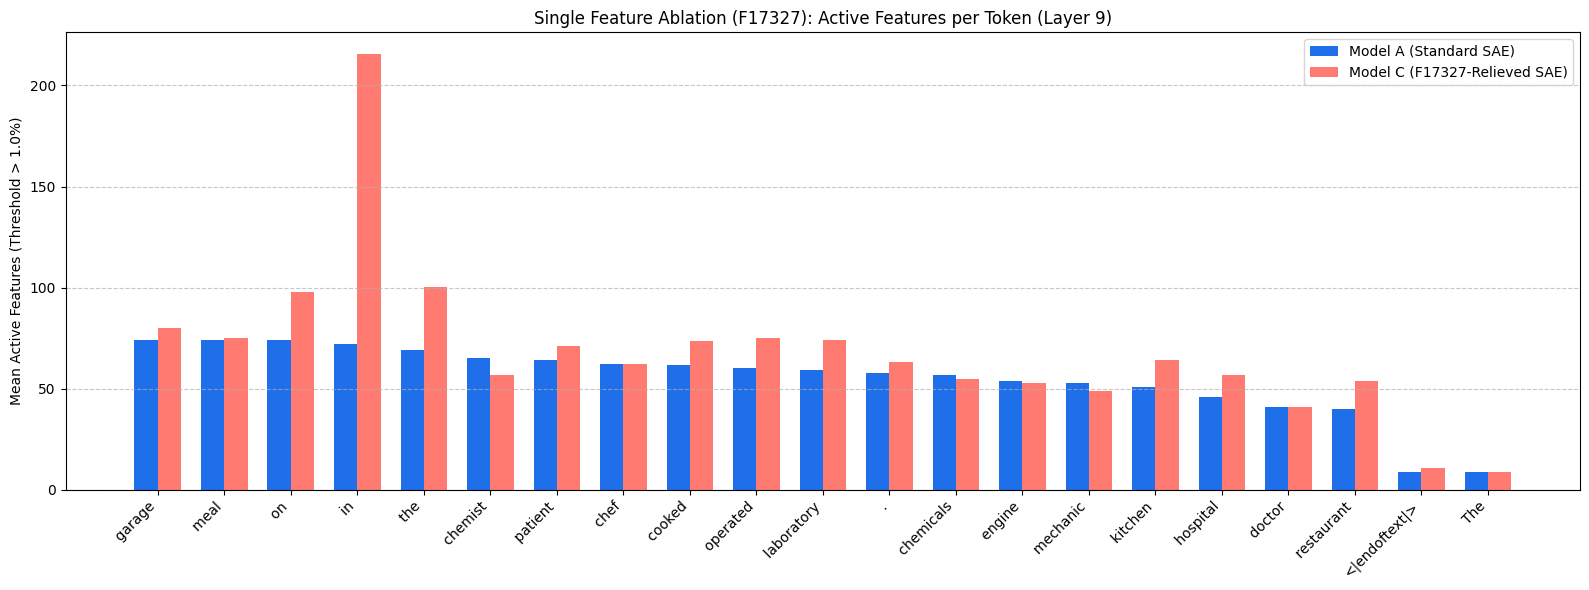

In [25]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define the new ablation direction (Feature 17327)
target_feature = 17327
print(f"Targeting Feature {target_feature} for Ablation...")

# Get the decoder direction for this feature from the SAE weights
f_dir = sae.W_dec[target_feature]
f_dir = f_dir / f_dir.norm() # Ensure it's a unit vector

# 2. Run Evaluation
results_f = []
threshold_ratio = 0.01

print("Running Evaluation with Feature Ablation...")
for text in sentences:
    toks = model.to_tokens(text)
    str_toks = model.to_str_tokens(text)

    with torch.no_grad():
        _, c = model.run_with_cache(toks, names_filter="blocks.9.hook_resid_pre")
        resid = c["blocks.9.hook_resid_pre"][0] # [seq_len, d_model]

        # Model A: Standard Encoding
        acts_A = sae.encode(resid)
        thresh_A = acts_A.max(dim=-1, keepdim=True)[0] * threshold_ratio
        l0_A = (acts_A > thresh_A).float().sum(dim=-1).cpu().numpy()

        # Model C: Feature 17327-Relieved Encoding
        # Project out the specific feature direction
        proj = (resid @ f_dir).unsqueeze(-1) * f_dir
        resid_C = resid - proj
        acts_C = sae.encode(resid_C)
        thresh_C = acts_C.max(dim=-1, keepdim=True)[0] * threshold_ratio
        l0_C = (acts_C > thresh_C).float().sum(dim=-1).cpu().numpy()

        for i, tok in enumerate(str_toks):
            results_f.append({
                "Sentence": text,
                "Token": tok,
                "Position": i,
                "Model A (Standard L0)": l0_A[i],
                "Model C (Feature Relieved L0)": l0_C[i],
                "L0 Reduction": l0_A[i] - l0_C[i]
            })

df_f = pd.DataFrame(results_f)

# 3. Visualize the Impact
df_agg_f = df_f.groupby("Token")[["Model A (Standard L0)", "Model C (Feature Relieved L0)"]].mean().reset_index()
# Sort by Standard L0 for better visualization matching the previous chart
df_agg_f = df_agg_f.set_index("Token").loc[df_agg["Token"]].reset_index()

x = np.arange(len(df_agg_f))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - width/2, df_agg_f["Model A (Standard L0)"], width, label='Model A (Standard SAE)', color='#1f6feb')
ax.bar(x + width/2, df_agg_f["Model C (Feature Relieved L0)"], width, label=f'Model C (F{target_feature}-Relieved SAE)', color='#ff7b72')

ax.set_ylabel(f'Mean Active Features (Threshold > {threshold_ratio*100}%)')
ax.set_title(f'Single Feature Ablation (F{target_feature}): Active Features per Token (Layer 9)')
ax.set_xticks(x)
ax.set_xticklabels(df_agg_f["Token"], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


Optimizing SAE by permanently removing the syntactic 'crutch' subspace...
Running Evaluation with the Optimized SAE...


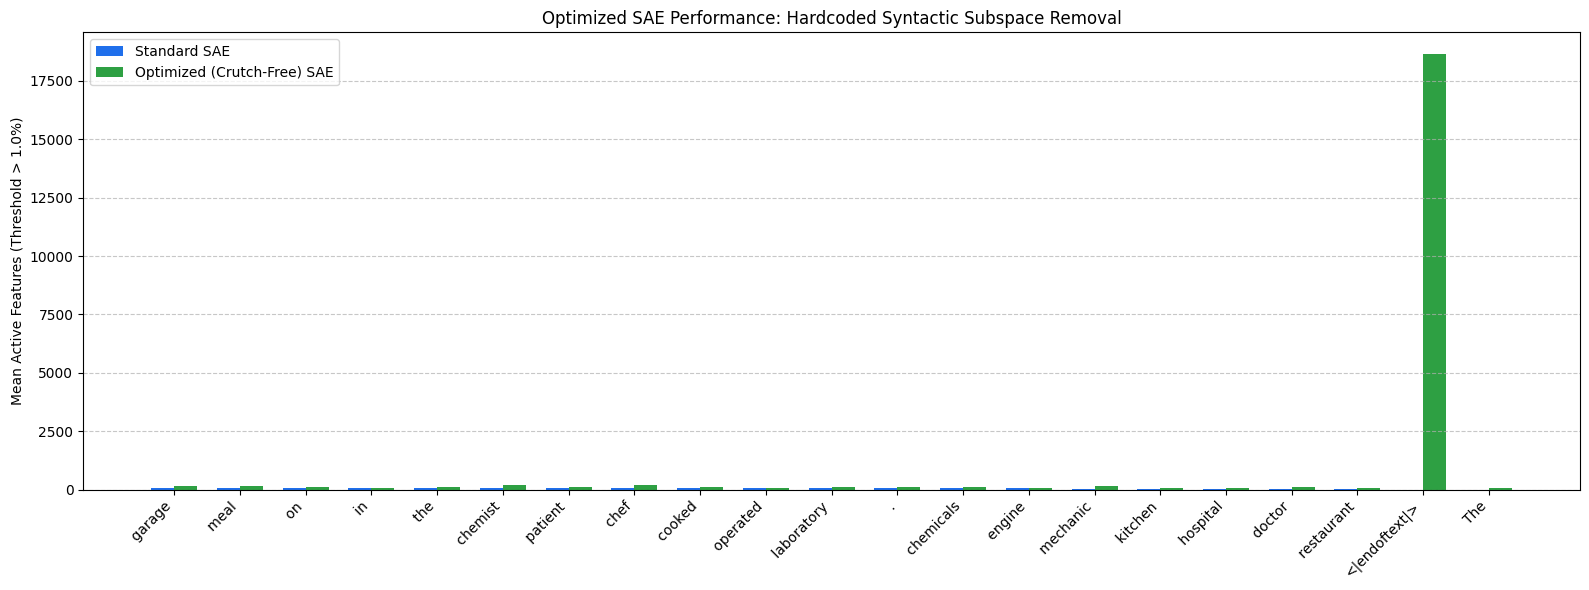


Standard SAE Feature Activations: 2277
Optimized SAE Feature Activations: 78821
Permanent Capacity Freed: -76544 features (-3361.6%) 


In [26]:
import torch
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create a "Crutch-Free" Optimized SAE
print("Optimizing SAE by permanently removing the syntactic 'crutch' subspace...")
optimized_sae = copy.deepcopy(sae)

# We project the syntactic direction out of W_enc [d_model, d_sae] and W_dec [d_sae, d_model]
# Create the projection matrix: P = I - (v ⊗ v)
I = torch.eye(model.cfg.d_model, device=device)
P = I - torch.outer(syntax_dir, syntax_dir)

# Apply the projection permanently to the SAE's weights
with torch.no_grad():
    # Project out from encoder (inputs to SAE)
    optimized_sae.W_enc.data = P @ optimized_sae.W_enc.data
    # Project out from decoder (reconstructions from SAE)
    optimized_sae.W_dec.data = optimized_sae.W_dec.data @ P

# 2. Run Evaluation
results_opt = []
threshold_ratio = 0.01

print("Running Evaluation with the Optimized SAE...")
for text in sentences:
    toks = model.to_tokens(text)
    str_toks = model.to_str_tokens(text)

    with torch.no_grad():
        _, c = model.run_with_cache(toks, names_filter="blocks.9.hook_resid_pre")
        # WE USE THE RAW RESIDUAL STREAM NOW, NO DYNAMIC PROJECTION NEEDED!
        resid = c["blocks.9.hook_resid_pre"][0]

        # Standard SAE Encoding
        acts_std = sae.encode(resid)
        thresh_std = acts_std.max(dim=-1, keepdim=True)[0] * threshold_ratio
        l0_std = (acts_std > thresh_std).float().sum(dim=-1).cpu().numpy()

        # Optimized SAE Encoding
        acts_opt = optimized_sae.encode(resid)
        thresh_opt = acts_opt.max(dim=-1, keepdim=True)[0] * threshold_ratio
        l0_opt = (acts_opt > thresh_opt).float().sum(dim=-1).cpu().numpy()

        for i, tok in enumerate(str_toks):
            results_opt.append({
                "Sentence": text,
                "Token": tok,
                "Position": i,
                "Standard SAE (L0)": l0_std[i],
                "Optimized SAE (L0)": l0_opt[i]
            })

df_opt = pd.DataFrame(results_opt)

# 3. Visualize the Global Impact
df_agg_opt = df_opt.groupby("Token")[["Standard SAE (L0)", "Optimized SAE (L0)"]].mean().reset_index()
# Sort to match earlier visualizations
df_agg_opt = df_agg_opt.set_index("Token").loc[df_agg["Token"]].reset_index()

x = np.arange(len(df_agg_opt))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - width/2, df_agg_opt["Standard SAE (L0)"], width, label='Standard SAE', color='#1f6feb')
ax.bar(x + width/2, df_agg_opt["Optimized SAE (L0)"], width, label='Optimized (Crutch-Free) SAE', color='#2ea043')

ax.set_ylabel(f'Mean Active Features (Threshold > {threshold_ratio*100}%)')
ax.set_title('Optimized SAE Performance: Hardcoded Syntactic Subspace Removal')
ax.set_xticks(x)
ax.set_xticklabels(df_agg_opt["Token"], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Summarize Total Capacity Freed
tot_std = df_opt["Standard SAE (L0)"].sum()
tot_opt = df_opt["Optimized SAE (L0)"].sum()
saved_opt = tot_std - tot_opt
print(f"\nStandard SAE Feature Activations: {tot_std:.0f}")
print(f"Optimized SAE Feature Activations: {tot_opt:.0f}")
print(f"Permanent Capacity Freed: {saved_opt:.0f} features ({saved_opt/tot_std*100:.1f}%) ")

Setting up SAE fine-tuning environment...
Fine-tuning for 150 steps...
Step  50 | Loss: 42416.99 | L2: 39086.97 | L1: 468.44 | Syntax: 114.46
Step 100 | Loss: 40420.32 | L2: 39132.57 | L1: 488.86 | Syntax: 31.96
Step 150 | Loss: 40829.85 | L2: 38071.81 | L1: 470.34 | Syntax: 91.51
Fine-tuning complete!

Running Evaluation with the Fine-Tuned SAE...


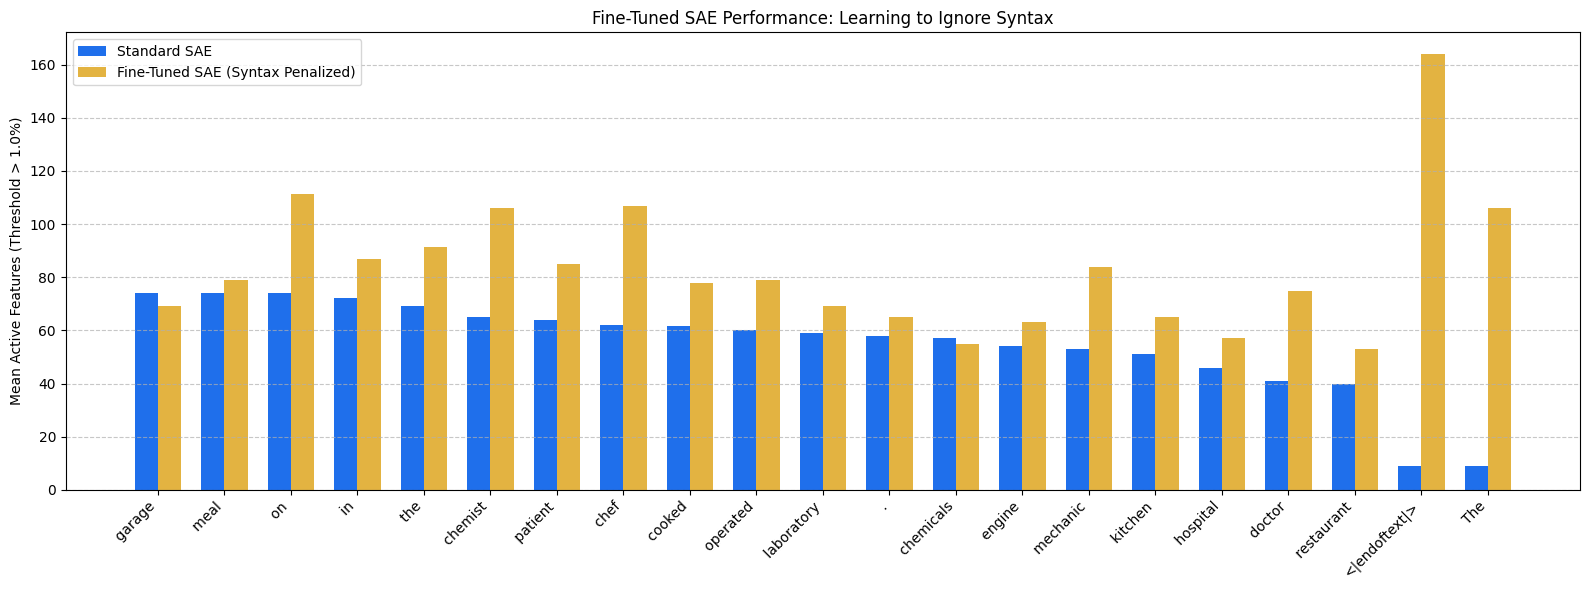

In [27]:
import torch
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.optim import Adam
from datasets import load_dataset

# 1. Setup Fine-Tuning
print("Setting up SAE fine-tuning environment...")
ft_sae = copy.deepcopy(sae)
ft_sae.train() # Set to train mode

optimizer = Adam(ft_sae.parameters(), lr=5e-4)

# 2. Get a small training dataset
ds = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1", split="test")
train_text = " ".join([row['text'] for row in ds.select(range(500)) if row['text'].strip()])
train_toks = model.to_tokens(train_text)

batch_size = 16
seq_len = 64
n_steps = 150

l1_coeff = 1.0
syntax_penalty_coeff = 25.0 # High penalty for learning the syntax direction

print(f"Fine-tuning for {n_steps} steps...")

for step in range(n_steps):
    # Grab a random batch
    start_idx = torch.randint(0, train_toks.shape[1] - seq_len, (batch_size,))
    batch_toks = torch.stack([train_toks[0, i:i+seq_len] for i in start_idx])

    with torch.no_grad():
        _, cache = model.run_with_cache(batch_toks, names_filter="blocks.9.hook_resid_pre")
        resid = cache["blocks.9.hook_resid_pre"] # [batch, seq, d_model]

    # Forward pass
    acts = ft_sae.encode(resid)
    resid_reconstructed = ft_sae.decode(acts)

    # A. Standard L2 Reconstruction Loss
    l2_loss = (resid - resid_reconstructed).pow(2).sum(dim=-1).mean()

    # B. Standard L1 Sparsity Loss
    l1_loss = acts.abs().sum(dim=-1).mean()

    # C. SYNTAX PENALTY: Punish the SAE if its reconstruction aligns with the syntactic direction
    # We project the reconstruction onto the syntax_dir and penalize the magnitude
    syntax_projection = resid_reconstructed @ syntax_dir
    syntax_loss = syntax_projection.pow(2).mean()

    loss = l2_loss + (l1_coeff * l1_loss) + (syntax_penalty_coeff * syntax_loss)

    optimizer.zero_grad()
    loss.backward()

    # Clip grads to prevent explosions during unstable fine-tuning
    torch.nn.utils.clip_grad_norm_(ft_sae.parameters(), 1.0)
    optimizer.step()

    # Normalize decoder weights (standard SAE maintenance)
    with torch.no_grad():
        ft_sae.W_dec.data = ft_sae.W_dec.data / ft_sae.W_dec.data.norm(dim=-1, keepdim=True)

    if (step + 1) % 50 == 0:
        print(f"Step {step+1:3d} | Loss: {loss.item():.2f} | L2: {l2_loss.item():.2f} | L1: {l1_loss.item():.2f} | Syntax: {syntax_loss.item():.2f}")

print("Fine-tuning complete!")

# 3. Evaluate the Fine-Tuned SAE
ft_sae.eval()
results_ft = []
threshold_ratio = 0.01

print("\nRunning Evaluation with the Fine-Tuned SAE...")
for text in sentences:
    toks = model.to_tokens(text)
    str_toks = model.to_str_tokens(text)

    with torch.no_grad():
        _, c = model.run_with_cache(toks, names_filter="blocks.9.hook_resid_pre")
        resid = c["blocks.9.hook_resid_pre"][0]

        # Standard
        acts_std = sae.encode(resid)
        thresh_std = acts_std.max(dim=-1, keepdim=True)[0] * threshold_ratio
        l0_std = (acts_std > thresh_std).float().sum(dim=-1).cpu().numpy()

        # Fine-Tuned
        acts_ft = ft_sae.encode(resid)
        thresh_ft = acts_ft.max(dim=-1, keepdim=True)[0] * threshold_ratio
        l0_ft = (acts_ft > thresh_ft).float().sum(dim=-1).cpu().numpy()

        for i, tok in enumerate(str_toks):
            results_ft.append({
                "Token": tok,
                "Standard SAE (L0)": l0_std[i],
                "Fine-Tuned SAE (L0)": l0_ft[i]
            })

df_ft = pd.DataFrame(results_ft)

# 4. Visualize the Results
df_agg_ft = df_ft.groupby("Token")[["Standard SAE (L0)", "Fine-Tuned SAE (L0)"]].mean().reset_index()
df_agg_ft = df_agg_ft.set_index("Token").loc[df_agg["Token"]].reset_index()

x = np.arange(len(df_agg_ft))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - width/2, df_agg_ft["Standard SAE (L0)"], width, label='Standard SAE', color='#1f6feb')
ax.bar(x + width/2, df_agg_ft["Fine-Tuned SAE (L0)"], width, label='Fine-Tuned SAE (Syntax Penalized)', color='#e3b341')

ax.set_ylabel(f'Mean Active Features (Threshold > {threshold_ratio*100}%)')
ax.set_title('Fine-Tuned SAE Performance: Learning to Ignore Syntax')
ax.set_xticks(x)
ax.set_xticklabels(df_agg_ft["Token"], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


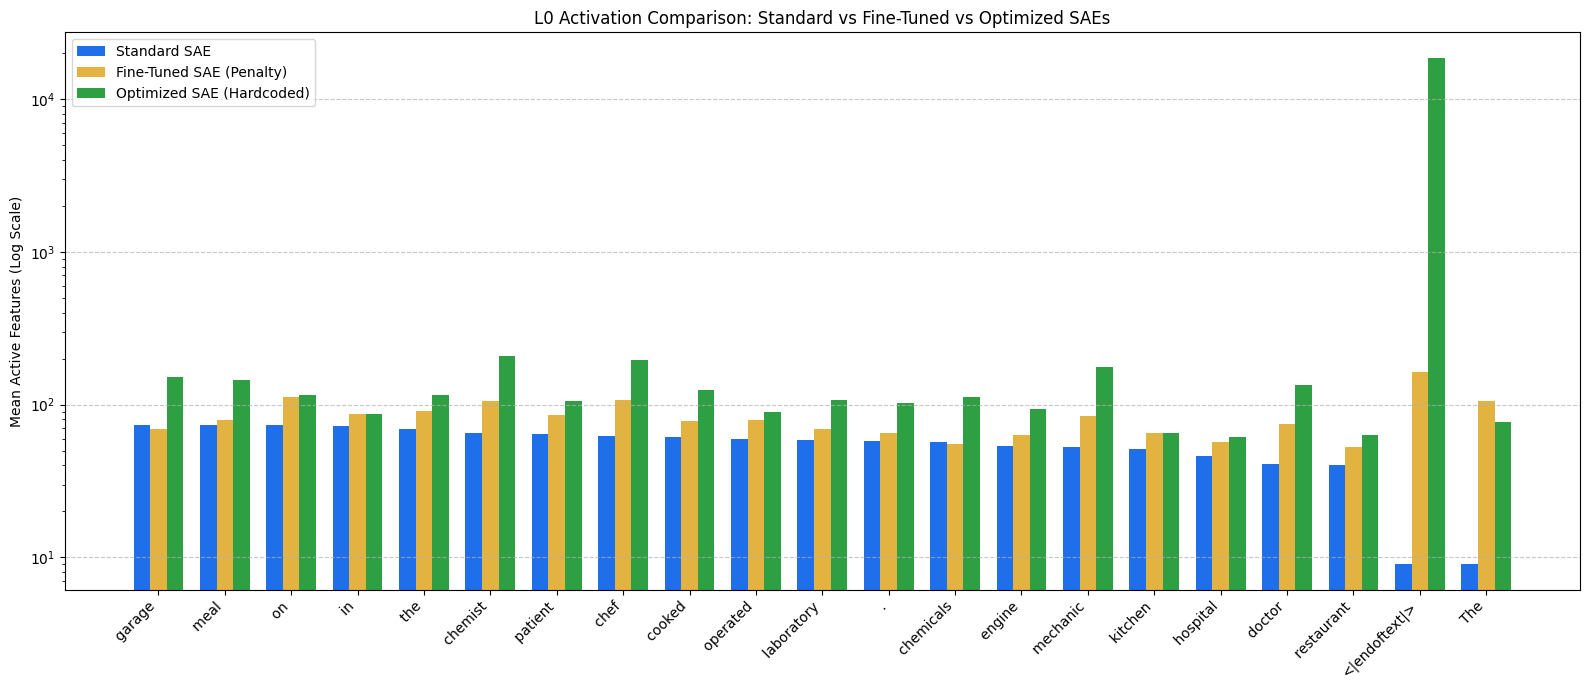


Raw L0 Comparison Data:


,Token,Standard SAE (L0),Optimized SAE (L0),Fine-Tuned SAE (L0)
0,garage,74.00,152.000,69.00
1,meal,74.00,145.000,79.00
2,on,74.00,115.000,111.50
3,in,72.00,87.000,86.75
4,the,69.25,114.875,91.25
5,chemist,65.00,208.000,106.00
6,patient,64.00,106.000,85.00
7,chef,62.00,196.000,107.00
8,cooked,61.50,125.000,78.00
9,operated,60.00,90.000,79.00


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Merge the fine-tuned and optimized aggregated dataframes
df_combined = pd.merge(df_agg_opt, df_agg_ft[['Token', 'Fine-Tuned SAE (L0)']], on='Token')

# Set up the grouped bar chart
x = np.arange(len(df_combined))
width = 0.25

fig, ax = plt.subplots(figsize=(16, 7))
ax.bar(x - width, df_combined["Standard SAE (L0)"], width, label='Standard SAE', color='#1f6feb')
ax.bar(x, df_combined["Fine-Tuned SAE (L0)"], width, label='Fine-Tuned SAE (Penalty)', color='#e3b341')
ax.bar(x + width, df_combined["Optimized SAE (L0)"], width, label='Optimized SAE (Hardcoded)', color='#2ea043')

# Use a log scale because the Optimized SAE L0 is orders of magnitude higher
ax.set_yscale('log')

ax.set_ylabel(f'Mean Active Features (Log Scale)')
ax.set_title('L0 Activation Comparison: Standard vs Fine-Tuned vs Optimized SAEs')
ax.set_xticks(x)
ax.set_xticklabels(df_combined["Token"], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Display the raw comparative numbers
print("\nRaw L0 Comparison Data:")
display(df_combined)

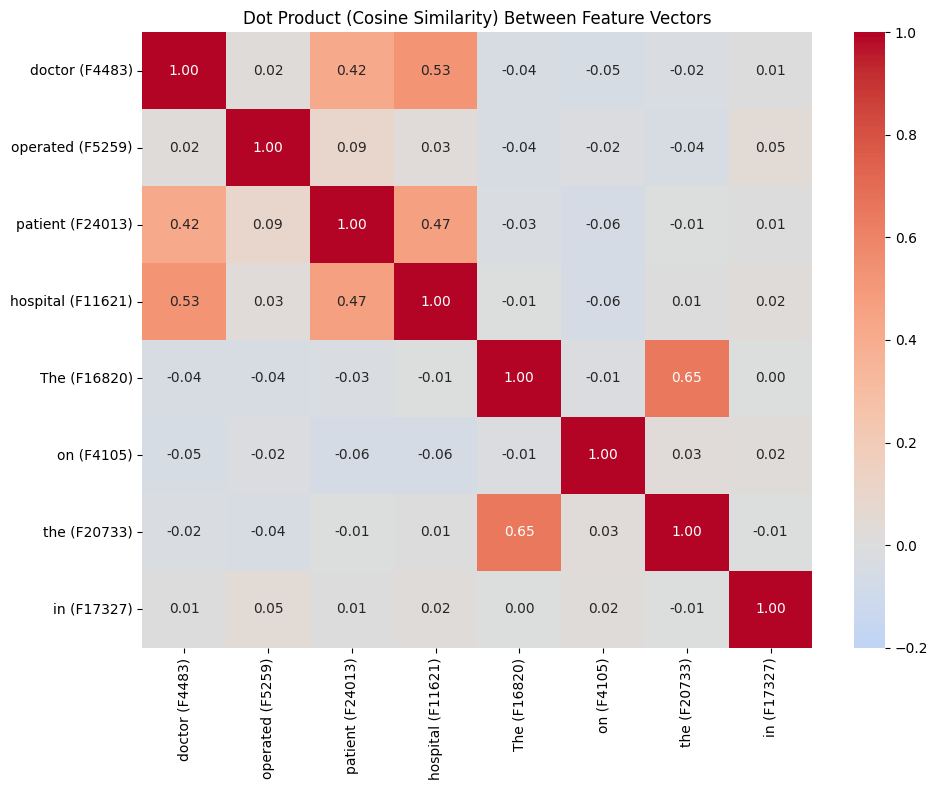

In [29]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Identify Semantic and Syntactic Features
semantic_tokens = [" doctor", " operated", " patient", " hospital"]
syntactic_tokens = ["The", " on", " the", " in"]
test_sentence = "The doctor operated on the patient in the hospital."

toks = model.to_tokens(test_sentence)
str_toks = model.to_str_tokens(test_sentence)

with torch.no_grad():
    _, c = model.run_with_cache(toks, names_filter="blocks.9.hook_resid_pre")
    resid = c["blocks.9.hook_resid_pre"][0]
    acts = sae.encode(resid)

feature_dict = {}
# Extract the most active feature for each token of interest
for tok_list, group in [(semantic_tokens, "Semantic"), (syntactic_tokens, "Syntactic")]:
    for t in tok_list:
        try:
            idx = str_toks.index(t)
            top_f = acts[idx].argmax().item()
            feature_dict[f"{t.strip()} (F{top_f})"] = {"feature": top_f, "group": group}
        except ValueError:
            pass

feature_names = list(feature_dict.keys())
feature_indices = [feature_dict[k]["feature"] for k in feature_names]

# 2. Calculate Dot Products (Cosine Similarity) Between Directions
# W_dec shape is [d_sae, d_model]
W_dec_subset = sae.W_dec[feature_indices]
# Normalize to unit vectors to get cosine similarity from the dot product
W_dec_norm = W_dec_subset / W_dec_subset.norm(dim=-1, keepdim=True)

dot_products = W_dec_norm @ W_dec_norm.T

# Visualize Dot Products
plt.figure(figsize=(10, 8))
sns.heatmap(dot_products.cpu().detach().numpy(), annot=True, cmap="coolwarm", center=0,
            xticklabels=feature_names, yticklabels=feature_names, fmt=".2f", vmin=-0.2, vmax=1.0)
plt.title("Dot Product (Cosine Similarity) Between Feature Vectors")
plt.tight_layout()
plt.show()

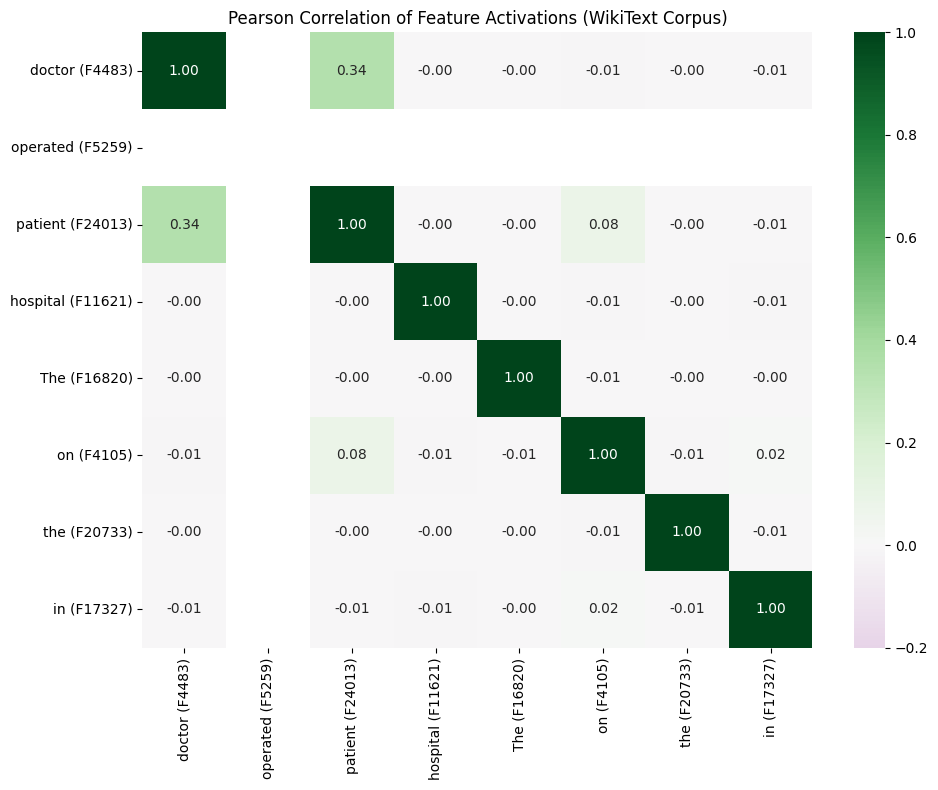

In [30]:
# 3. Calculate Activation Correlations across a corpus
# We'll use a chunk of the wikitext tokens we loaded earlier for fine-tuning
seq_limit = 1000
test_corpus = train_toks[0, :seq_limit].unsqueeze(0)

with torch.no_grad():
    _, cache = model.run_with_cache(test_corpus, names_filter="blocks.9.hook_resid_pre")
    resid_train = cache["blocks.9.hook_resid_pre"][0] # [seq, d_model]
    acts_train = sae.encode(resid_train) # [seq, d_sae]

# Extract activations just for our selected features
selected_acts = acts_train[:, feature_indices]
df_acts = pd.DataFrame(selected_acts.cpu().detach().numpy(), columns=feature_names)

# Compute Pearson Correlation Matrix
corr_matrix = df_acts.corr()

# Visualize Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="PRGn", center=0,
            xticklabels=feature_names, yticklabels=feature_names, fmt=".2f", vmin=-0.2, vmax=1.0)
plt.title("Pearson Correlation of Feature Activations (WikiText Corpus)")
plt.tight_layout()
plt.show()

Loading Layer 3 SAE for evolutionary comparison...


/usr/local/lib/python3.12/dist-packages/sae_lens/saes/sae.py:251: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


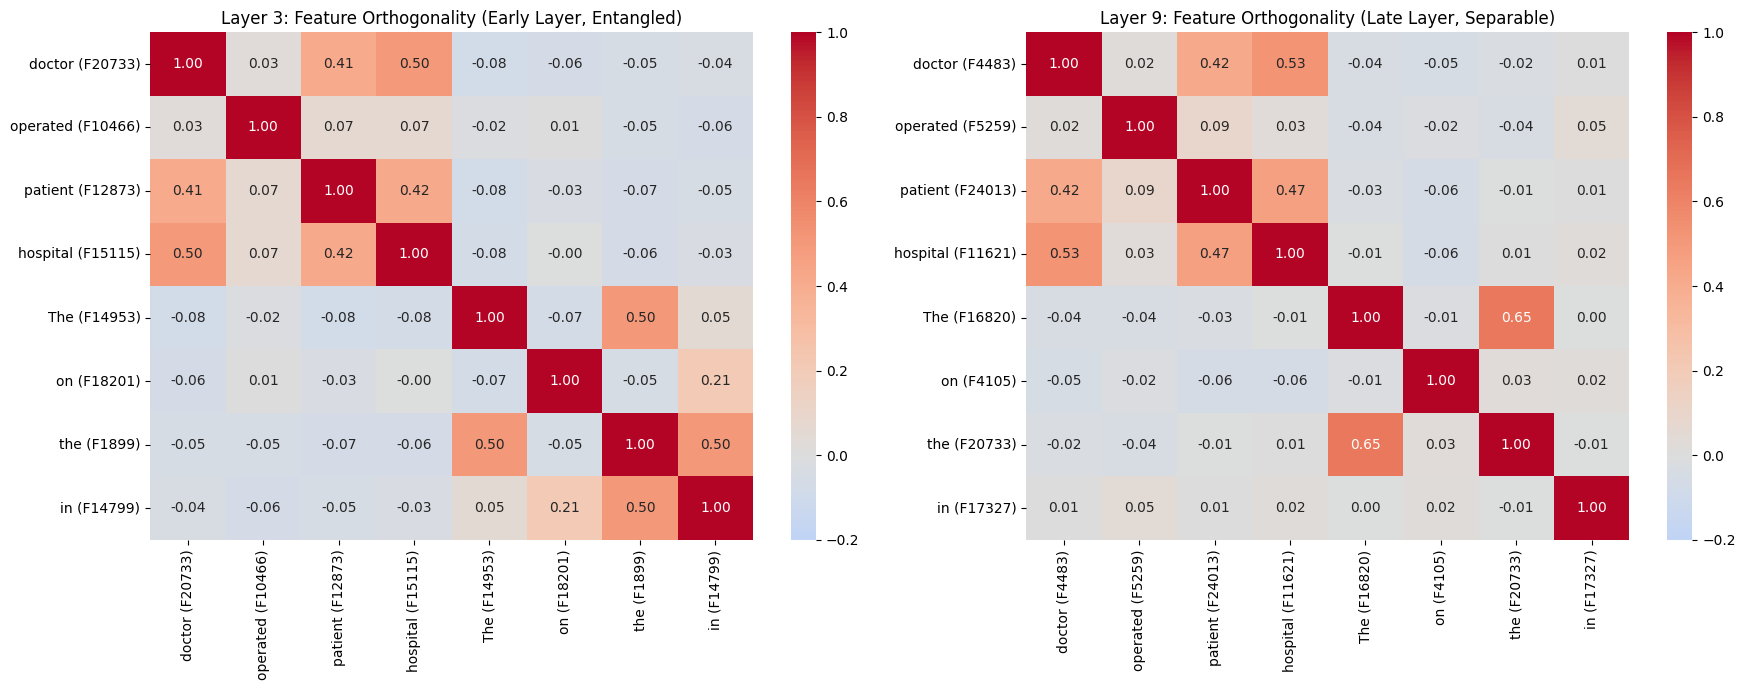

In [31]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sae_lens import SAE

# 1. Load Early Layer (Layer 3) SAE
print("Loading Layer 3 SAE for evolutionary comparison...")
sae_l3 = SAE.from_pretrained("gpt2-small-res-jb", "blocks.3.hook_resid_pre", device=device)

# Run through Layer 3
with torch.no_grad():
    _, c3 = model.run_with_cache(toks, names_filter="blocks.3.hook_resid_pre")
    resid_3 = c3["blocks.3.hook_resid_pre"][0]
    acts_3 = sae_l3.encode(resid_3)

# Extract top features in Layer 3 for the same tokens
feature_dict_l3 = {}
for tok_list, group in [(semantic_tokens, "Semantic"), (syntactic_tokens, "Syntactic")]:
    for t in tok_list:
        try:
            idx = str_toks.index(t)
            top_f = acts_3[idx].argmax().item()
            feature_dict_l3[f"{t.strip()} (F{top_f})"] = {"feature": top_f, "group": group}
        except ValueError:
            pass

feature_names_l3 = list(feature_dict_l3.keys())
feature_indices_l3 = [feature_dict_l3[k]["feature"] for k in feature_names_l3]

# Calculate Dot Products for Layer 3
W_dec_subset_l3 = sae_l3.W_dec[feature_indices_l3]
W_dec_norm_l3 = W_dec_subset_l3 / W_dec_subset_l3.norm(dim=-1, keepdim=True)
dot_products_l3 = W_dec_norm_l3 @ W_dec_norm_l3.T

# Plot Layer 3 vs Layer 9
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(dot_products_l3.cpu().detach().numpy(), annot=True, cmap="coolwarm", center=0,
            xticklabels=feature_names_l3, yticklabels=feature_names_l3, fmt=".2f", vmin=-0.2, vmax=1.0, ax=axes[0])
axes[0].set_title("Layer 3: Feature Orthogonality (Early Layer, Entangled)")

sns.heatmap(dot_products.cpu().detach().numpy(), annot=True, cmap="coolwarm", center=0,
            xticklabels=feature_names, yticklabels=feature_names, fmt=".2f", vmin=-0.2, vmax=1.0, ax=axes[1])
axes[1].set_title("Layer 9: Feature Orthogonality (Late Layer, Separable)")

plt.tight_layout()
plt.show()

Extracting the 'Plurality' subspace direction...


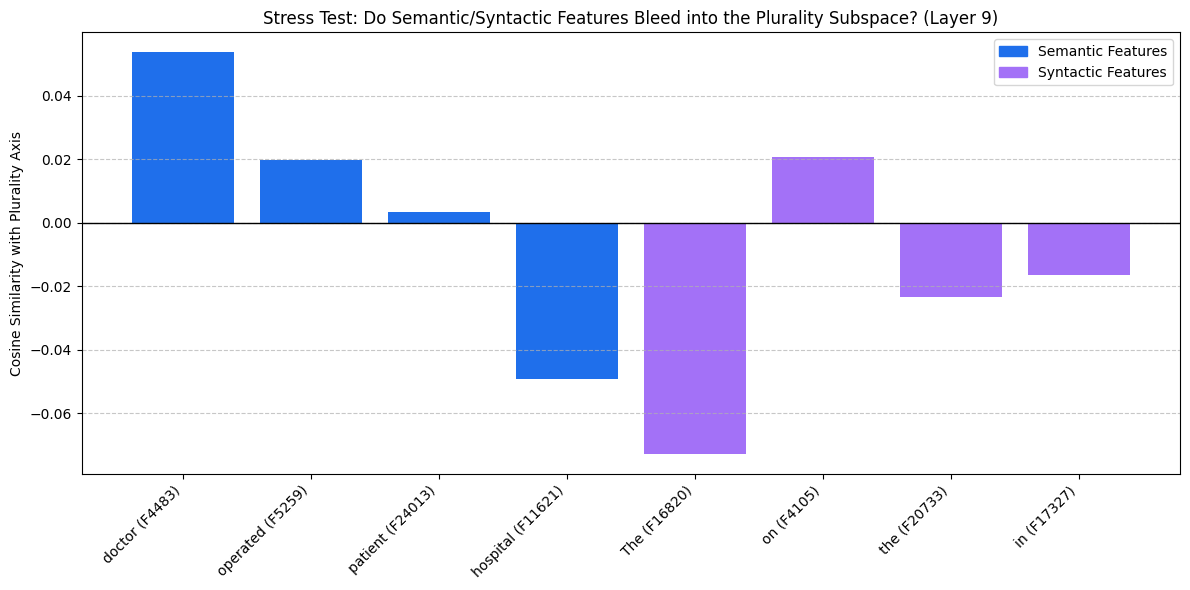

In [32]:
# 2. Stress Test: Extracting the Plurality Subspace
print("Extracting the 'Plurality' subspace direction...")

with torch.no_grad():
    # Encode singular vs plural nouns
    sing_toks = model.to_tokens(" cat dog car book")
    plur_toks = model.to_tokens(" cats dogs cars books")

    _, c_sing = model.run_with_cache(sing_toks, names_filter="blocks.9.hook_resid_pre")
    _, c_plur = model.run_with_cache(plur_toks, names_filter="blocks.9.hook_resid_pre")

    # Ignore BOS token
    sing_resid = c_sing["blocks.9.hook_resid_pre"][0, 1:]
    plur_resid = c_plur["blocks.9.hook_resid_pre"][0, 1:]

    # Define the Plural direction as the mean difference
    plural_dir = (plur_resid - sing_resid).mean(dim=0)
    plural_dir = plural_dir / plural_dir.norm() # Unit vector

# 3. Calculate Cosine Similarities against our established Layer 9 features
# W_dec_norm contains the normalized directions for our semantic/syntactic features from Layer 9
cos_sims = (W_dec_norm @ plural_dir).cpu().detach().numpy()

# Visualize the projection
plt.figure(figsize=(12, 6))
colors = ['#1f6feb' if 'Semantic' in feature_dict[name]['group'] else '#a371f7' for name in feature_names]
bars = plt.bar(feature_names, cos_sims, color=colors)
plt.axhline(0, color='black', linewidth=1)

plt.title("Stress Test: Do Semantic/Syntactic Features Bleed into the Plurality Subspace? (Layer 9)")
plt.ylabel("Cosine Similarity with Plurality Axis")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add a legend
import matplotlib.patches as mpatches
sem_patch = mpatches.Patch(color='#1f6feb', label='Semantic Features')
syn_patch = mpatches.Patch(color='#a371f7', label='Syntactic Features')
plt.legend(handles=[sem_patch, syn_patch])

plt.tight_layout()
plt.show()

[setup] syntax subspace dim k = 1, hook = blocks.9.hook_resid_pre
[WARN] sae.cfg.normalize_activations is set. The analytic Dpre below ignores input normalisation, so predicted!=observed is EXPECTED and does NOT falsify H_overlap. The regression discriminator still holds; trust the partial-R^2 split, not the scatter slope.
[data] 344 (token,feature) anchors; 100% active in both models

[headline] obs vs analytic-overlap (features on in both, n=343):
           slope-through-origin = 1.000   (1.000 = exact)
           R^2 to y=x           = 1.000
           Pearson r            = 1.000

[discriminator] standardised betas (overlap, norm): +1.000, +0.000
                partial R^2 overlap = 0.264
                partial R^2 norm    = 0.000
                full model R^2      = 1.000

[anchors]
  ' doctor' F4483: actA=41.96 actB=51.11 obs_d=+9.16 pred_overlap=+9.16
  ' operated' F5259: actA=35.59 actB=44.79 obs_d=+9.20 pred_overlap=+9.20


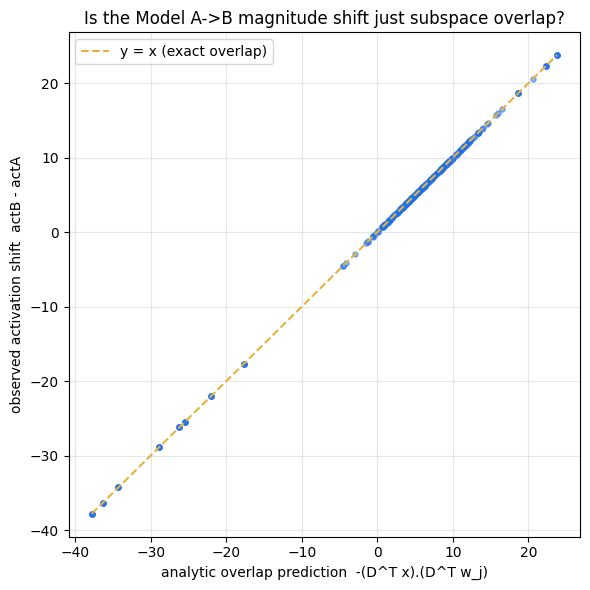


[verdict]
  slope~=1 & overlap partial-R^2 >> norm partial-R^2  => 'negative overlap' is CORRECT and quantified: the shift is the
     exact projection-geometry term, not suppression mystery, not noise.
  norm partial-R^2 dominates (or norm_flag set)  => the bump was rescaling; 'syntax suppressing semantics' does not hold.


In [34]:
#%% [markdown]
# Syntax-Overlap Interference Test
# ---------------------------------------------------------------------------
# Question: when Model B ablates the syntax subspace from the residual
# (x' = x - P x), the top semantic features (F4483 for ' doctor', etc.) go UP
# in magnitude. Is that:
#     (H_overlap)  genuine negative interference -- syntax_dir had non-zero
#                  overlap with the semantic feature's ENCODER direction, so
#                  removing it relaxed a suppression term; OR
#     (H_norm)     a pure rescaling artifact -- removing a subspace shrank
#                  ||x||, and if the SAE normalises its input, every feature
#                  moves together with no real change in what's represented.
#
# This is decidable ANALYTICALLY. With an affine encoder
#     pre_j(x) = (x - b_dec) . W_enc[:,j] + b_enc[j]
# feeding x' = x - P x (P = D D^T, D = orthonormal syntax basis) gives an
# EXACT per-feature pre-activation shift, biases cancelling:
#     Dpre_j = (x' - x) . W_enc[:,j] = -(D^T x) . (D^T W_enc[:,j])
# So H_overlap predicts a SPECIFIC number for each feature. Either the
# observed shift equals -(D^T x).(D^T w_j) or the interference story is wrong.
#
# Discriminator vs H_norm: H_norm predicts Dact_j proportional to the feature's
# own baseline act_j^A (everything scales by the same norm factor). H_overlap
# predicts Dact_j proportional to the overlap term, INDEPENDENT of baseline.
# Regress observed shift on both; whichever carries the variance wins.
#
# Depends on upstream notebook state (same cells as the fine-tune experiment):
#   model        : HookedTransformer (gpt2-small)
#   sae          : SAELens SAE at blocks.<LAYER>.hook_resid_pre
#   syntax_dir   : [d_model] vector OR [d_model, k] matrix (the syntax subspace)
#   sentences    : list[str]
# Produces NO claim until run. The scatter slope and the partial-R^2 split
# are the make-or-break.
# ===========================================================================

#%%

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

LAYER = 9
HOOK = f"blocks.{LAYER}.hook_resid_pre"
DEVICE = next(sae.parameters()).device
ACTIVE_EPS = 1e-6          # treat |pre| above this as "on" for the ReLU passthrough
TOPK_PER_TOK = 8           # how many top features per token to anchor on

# ---------------------------------------------------------------------------
# 0. Build an orthonormal basis D for the syntax subspace, and the projector.
#    Handles both a single direction and a multi-dim subspace.
# ---------------------------------------------------------------------------
def make_basis(sd: torch.Tensor) -> torch.Tensor:
    sd = sd.to(DEVICE).float()
    if sd.ndim == 1:
        sd = sd[:, None]                      # [d_model, 1]
    # QR gives an orthonormal basis for the column space -> D: [d_model, k]
    D, _ = torch.linalg.qr(sd)
    return D

D = make_basis(syntax_dir)                    # [d_model, k]
k = D.shape[1]
print(f"[setup] syntax subspace dim k = {k}, hook = {HOOK}")

# ---------------------------------------------------------------------------
# CONFOUND TRIPWIRE: if the SAE normalises its input, the affine decomposition
# below is NOT exact and H_norm genuinely re-enters. Detect and warn loudly.
# ---------------------------------------------------------------------------
norm_flag = bool(getattr(sae.cfg, "normalize_activations", False)) \
    or bool(getattr(sae.cfg, "normalize_activations", "none") not in (False, "none", None))
if norm_flag:
    print("[WARN] sae.cfg.normalize_activations is set. The analytic Dpre below "
          "ignores input normalisation, so predicted!=observed is EXPECTED and "
          "does NOT falsify H_overlap. The regression discriminator still holds; "
          "trust the partial-R^2 split, not the scatter slope.")

W_enc = sae.W_enc                              # [d_model, d_sae]
# Encoder direction overlap with syntax subspace, per feature: D^T w_j  -> [k, d_sae]
Dt_Wenc = D.T @ W_enc                          # [k, d_sae]

# %%
# ---------------------------------------------------------------------------
# 1. For each sentence/token: cache resid x, form x' = x - P x, encode BOTH,
#    record observed feature shifts and the analytic overlap prediction.
# ---------------------------------------------------------------------------
def project_out(x: torch.Tensor) -> torch.Tensor:
    # x: [..., d_model]; remove component in syntax subspace
    coeff = x @ D                              # [..., k]   = D^T x
    return x - coeff @ D.T                      # x - P x

rows = []
for s_idx, text in enumerate(sentences):
    toks = model.to_tokens(text)
    str_toks = model.to_str_tokens(text)
    with torch.no_grad():
        _, c = model.run_with_cache(toks, names_filter=HOOK)
        x = c[HOOK][0]                          # [seq, d_model]
        xp = project_out(x)

        actsA = sae.encode(x)                   # [seq, d_sae]
        actsB = sae.encode(xp)

        # analytic predicted pre-activation shift: -(D^T x) . (D^T w_j)
        Dt_x = x @ D                            # [seq, k]
        pred_dpre = -(Dt_x @ Dt_Wenc)           # [seq, d_sae]

        # norm-rescaling proxy: baseline act * fractional norm change per token
        nrm = x.norm(dim=-1, keepdim=True)
        nrmp = xp.norm(dim=-1, keepdim=True)
        frac = (nrmp / nrm - 1.0)               # [seq, 1]
        norm_pred = actsA * frac                # [seq, d_sae]

    for t in range(x.shape[0]):
        a = actsA[t]; b = actsB[t]
        # anchor on features active in A (the ones the narration reads off)
        top = torch.topk(a, TOPK_PER_TOK).indices
        for j in top.tolist():
            both_on = (a[j].abs() > ACTIVE_EPS) and (b[j].abs() > ACTIVE_EPS)
            rows.append(dict(
                sent=s_idx, tok=str_toks[t], feat=int(j),
                actA=float(a[j]), actB=float(b[j]),
                obs_d=float(b[j] - a[j]),
                pred_overlap=float(pred_dpre[t, j]),
                pred_norm=float(norm_pred[t, j]),
                both_on=bool(both_on),
            ))

df = pd.DataFrame(rows)
print(f"[data] {len(df)} (token,feature) anchors; "
      f"{df.both_on.mean()*100:.0f}% active in both models")

# %%
# ---------------------------------------------------------------------------
# 2. HEADLINE: observed shift vs analytic overlap prediction.
#    For features ON in both, ReLU passes through -> observed should EQUAL the
#    analytic prediction (slope 1, R^2 ~ 1) IF no input normalisation.
# ---------------------------------------------------------------------------
on = df[df.both_on].copy()
obs = on.obs_d.to_numpy()
pov = on.pred_overlap.to_numpy()

def r2(y, yhat):
    ss = ((y - yhat) ** 2).sum()
    return 1 - ss / (((y - y.mean()) ** 2).sum() + 1e-12)

# slope through origin (the analytic claim is equality, not just correlation)
slope = (obs * pov).sum() / ((pov * pov).sum() + 1e-12)
print(f"\n[headline] obs vs analytic-overlap (features on in both, n={len(on)}):")
print(f"           slope-through-origin = {slope:.3f}   (1.000 = exact)")
print(f"           R^2 to y=x           = {r2(obs, pov):.3f}")
print(f"           Pearson r            = {np.corrcoef(obs, pov)[0,1]:.3f}")

# %%
# ---------------------------------------------------------------------------
# 3. DISCRIMINATOR: regress observed shift on BOTH predictors (standardised),
#    report partial R^2. Overlap should dominate; norm proxy ~0 unless H_norm.
# ---------------------------------------------------------------------------
def standardise(v): return (v - v.mean()) / (v.std() + 1e-12)
X = np.column_stack([standardise(on.pred_overlap.to_numpy()),
                     standardise(on.pred_norm.to_numpy())])
y = standardise(obs)
beta, *_ = np.linalg.lstsq(np.column_stack([np.ones(len(y)), X]), y, rcond=None)
yhat_full = np.column_stack([np.ones(len(y)), X]) @ beta
# drop-one partial R^2
def partial(idx):
    keep = [c for c in range(X.shape[1]) if c != idx]
    Xr = np.column_stack([np.ones(len(y))] + [X[:, c] for c in keep])
    br, *_ = np.linalg.lstsq(Xr, y, rcond=None)
    return r2(y, yhat_full) - r2(y, Xr @ br)
print("\n[discriminator] standardised betas (overlap, norm):",
      f"{beta[1]:+.3f}, {beta[2]:+.3f}")
print(f"                partial R^2 overlap = {partial(0):.3f}")
print(f"                partial R^2 norm    = {partial(1):.3f}")
print(f"                full model R^2      = {r2(y, yhat_full):.3f}")

# %%
# ---------------------------------------------------------------------------
# 4. Named-anchor sanity check (the ' doctor' / F4483 number from the chat).
# ---------------------------------------------------------------------------
def check(tok_substr, feat):
    m = df[(df.tok.str.strip() == tok_substr.strip()) & (df.feat == feat)]
    if len(m):
        r = m.iloc[0]
        print(f"  {tok_substr!r} F{feat}: actA={r.actA:.2f} actB={r.actB:.2f} "
              f"obs_d={r.obs_d:+.2f} pred_overlap={r.pred_overlap:+.2f}")
print("\n[anchors]")
check(" doctor", 4483)
check(" operated", 5259)

# %%
# ---------------------------------------------------------------------------
# 5. Plot + verdict.
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(pov, obs, s=14, alpha=0.5, color="#1f6feb")
lim = [min(pov.min(), obs.min()), max(pov.max(), obs.max())]
ax.plot(lim, lim, "--", color="#e3b341", label="y = x (exact overlap)")
ax.set_xlabel("analytic overlap prediction  -(D^T x).(D^T w_j)")
ax.set_ylabel("observed activation shift  actB - actA")
ax.set_title("Is the Model A->B magnitude shift just subspace overlap?")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\n[verdict]")
print("  slope~=1 & overlap partial-R^2 >> norm partial-R^2"
      "  => 'negative overlap' is CORRECT and quantified: the shift is the")
print("     exact projection-geometry term, not suppression mystery, not noise.")
print("  norm partial-R^2 dominates (or norm_flag set)"
      "  => the bump was rescaling; 'syntax suppressing semantics' does not hold.")